# Labor-cost decomposition: organization and nested teams

## 1. Methodology summary

Employee-month records build **workforce states**. SHAP switches aggregate business drivers, never employees.
We compare January/A → February/B: **0 selects A; 1 selects B**. Every distribution switches as a whole.

```text
Total labor cost
├── Workforce scale
├── Team mix
└── Team economics (one branch per team)
    ├── Contract type mix
    ├── Temp reimbursement
    ├── Outsource reimbursement
    └── Permanent unit cost
        ├── Regional coefficient-band mix
        ├── Grade composition within region
        ├── Within-team/region/grade salary level
        ├── Worked hours (salary-weighted)
        └── Nine separate payment drivers
```

The **organizational bridge** reconciles the organization's change. A **local team bridge** first separates
that team's scale and unit economics, then uses the same nested economics games. It reconciles that team's
own change. These views allocate scale interactions differently; **do not combine their impacts**.
This is the stated hierarchy's accounting attribution, not an unrestricted flat-player or causal Shapley game.

The primary example is **SYNTHETIC**, with three teams and independently calculated employee payroll.
The optional [legacy mock example](#legacy-mock) keeps its limited observed drivers and reconstructed reference.
Production inputs are Pandas DataFrames. See [methodology](docs/labor-cost-decomposition.md) for requirements.


## 2. Imports and configuration


In [1]:
from copy import deepcopy
from dataclasses import dataclass
from itertools import product
from math import factorial
from pathlib import Path
from io import StringIO
from typing import Callable
from textwrap import fill
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
with warnings.catch_warnings():
    # Exact enumeration does not need optional notebook progress widgets.
    warnings.filterwarnings('ignore', message='IProgress not found.*', module='tqdm.auto')
    import shap
from IPython.display import display, Markdown

RTOL, ATOL, PROB_ATOL = 1e-10, 1e-6, 1e-12
PERIOD_A, PERIOD_B = pd.Timestamp('2026-01-01'), pd.Timestamp('2026-02-01')
CONTRACTS = ('permanent', 'temporary', 'outsourced')
PARENT = 'permanent_unit_cost'
FALLBACK_ORDER = ('grade', 'region', 'global')
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
display(pd.Series({'python': platform.python_version(), 'pandas': pd.__version__,
                   'numpy': np.__version__, 'shap': shap.__version__}, name='versions'))


from time import perf_counter
NOTEBOOK_STARTED = perf_counter()
MAX_EXACT_DRIVERS = 14
TEAM_PARENT = 'team_economics'
TEAMS = ('Operations A', 'Operations B', 'Operations C')

def check(name, actual, expected):
    np.testing.assert_allclose(actual, expected, rtol=RTOL, atol=ATOL, err_msg=name)
    error = float(np.max(np.abs(np.asarray(actual)-np.asarray(expected)), initial=0))
    return {'check': name, 'maximum_absolute_error': error, 'passed': True}

def show(title, value):
    display(Markdown('**'+title+'**'))
    display(value)


python    3.10.12
pandas      2.3.3
numpy      1.26.4
shap       0.48.0
Name: versions, dtype: object

## 3. Production schema and synthetic employee-month data

One employee-month has exactly one recorded team. Sharing pay belongs to that team; there is no receiving-team
cost transfer. Team names are exact identities: reconcile organizational renames before supplying the frame.
`region_{reg_coef}` identifies a **coefficient band**, not physical geography. A/B coefficients are fixed
parameters; these source fields alone cannot identify a policy change separately from movement between bands.

Canonical schema: `period` is a datetime month start; `employee_id`, `team`, and `contract_type` are nonempty
strings; `exposure` is in (0,1]; `region` and `grade` identify permanent-worker cells; `base_salary` is positive;
`worked_fraction` is finite and nonnegative (values above one are allowed); payment and reimbursement columns
are finite nonnegative currency **per exposure**. `source_cost` is actual employee-month currency, never divided
by a regional coefficient. Permanent fields are required on permanent rows; reimbursement is required on other
contracts. Inapplicable fields can be null. Applicable missing amounts are errors, not assumed zero payments.

Production `exposure=1` counts recorded employee-months. `vyrabotka_percent=0.8` means 80%; it already enters the
employee formula. **No extra availability multiplier** is applied by the production adapter. For an explicitly
exposure-weighted canonical dataset, salary and payment inputs must be per exposure, so source cost equals
exposure × the employee unit formula. Exposure and worked time are separate concepts.

Eligible inputs are **pre-regional**. KPI is the realized payout; quarterly bonuses enter the recorded month.
Vacation and holiday pay are separate. Other bundled pay is an explicit input, not a reconciliation plug.
The table below is the exact production mapping. With `source_cost_column=None`, permanent reference costs
are reconstructed; GPD/PKC use supplied payroll. An optional independent actual-cost column covers all rows.

Synthetic employee characteristics are drawn afresh each month, with team-specific salary trends
(+4.5%, −1%, +2.5%) and worked-time trends. Matched synthetic salary changes therefore also reflect
those newly drawn characteristics; they are not a longitudinal pay-policy estimate.


In [2]:
PRODUCTION_COLUMNS = {
    'period': 'period', 'mdm_employee_rk_hash': 'employee_id',
    'lvl7_mapped_management_unit_nm': 'team', 'motivation_type': 'contract_type',
    'grade': 'grade', 'reg_coef': 'regional_coefficient',
    'base_stavka': 'base_salary', 'vyrabotka_percent': 'worked_fraction',
    'sum_pay_bl_reg_base': 'sick_leave_pay', 'sum_pay_otpusk_reg_base': 'vacation_pay',
    'sum_pay_prazdnik_reg_base': 'holiday_pay', 'sum_pay_oklad_night_reg_base': 'night_shift_pay',
    'bonus_kpi_comp': 'bonus_kpi', 'bonus_overtime_comp': 'overtime_pay',
    'bonus_sharing_comp_reg_base': 'sharing_bonus',
    'bonus_quarterly_comp_reg_base': 'quarterly_bonus', 'sum_pay_compacted': 'other_pay',
    'gpd_pay': 'gpd_pay', 'pkc_pay': 'pkc_pay',
}
PRODUCTION_CONTRACTS = {'ТК': 'permanent', 'ГПД': 'temporary', 'ПКЦ': 'outsourced'}
PAYMENT_COLUMNS = ('sick_leave_pay', 'vacation_pay', 'holiday_pay', 'night_shift_pay',
                   'bonus_kpi', 'overtime_pay', 'sharing_bonus', 'quarterly_bonus', 'other_pay')

def band_name(value):
    return 'region_' + str(float(value))

def employee_payroll_reference(frame):
    """Independent employee-record formula; deliberately does not call the cost engine/registry."""
    p = frame.contract_type.eq('permanent')
    result = frame.contract_reimbursement.copy()
    r = frame.loc[p]
    result.loc[p] = (
        r.regional_coefficient * (r.base_salary*r.worked_fraction + r.sick_leave_pay
            + r.vacation_pay + r.holiday_pay + r.night_shift_pay)
        + r.bonus_kpi + r.overtime_pay
        + r.regional_coefficient*(r.sharing_bonus + r.quarterly_bonus) + r.other_pay)
    return result * frame.exposure

def adapt_production(frame, *, source_cost_column=None):
    missing = set(PRODUCTION_COLUMNS) - set(frame.columns)
    if missing:
        raise ValueError(f'Missing production columns: {sorted(missing)}')
    out = frame[list(PRODUCTION_COLUMNS)].rename(columns=PRODUCTION_COLUMNS).copy()
    if not out.contract_type.isin(PRODUCTION_CONTRACTS).all():
        raise ValueError('Unknown production motivation_type (expected ТК, ГПД, ПКЦ)')
    out['contract_type'] = out.contract_type.map(PRODUCTION_CONTRACTS)
    out['period'] = pd.to_datetime(out.period, errors='raise')
    out['exposure'] = 1.0
    p = out.contract_type.eq('permanent')
    factors = out.loc[p, 'regional_coefficient']
    if not pd.api.types.is_numeric_dtype(factors) or not np.isfinite(factors).all() or (factors <= 0).any():
        raise ValueError('Permanent reg_coef must be finite and positive')
    out['region'] = None
    out.loc[p, 'region'] = factors.map(band_name)
    out['contract_reimbursement'] = np.where(out.contract_type.eq('temporary'), out.gpd_pay, out.pkc_pay)
    out['source_cost'] = (employee_payroll_reference(out) if source_cost_column is None
                          else frame[source_cost_column].copy())
    out['reference_basis'] = ('independent supplied source cost' if source_cost_column is not None
                              else np.where(p, 'reconstructed permanent payroll', 'supplied contract payroll'))
    validate_input(out)  # Defined in section 5; the adapter is first called there.
    return out

show('Production → canonical mapping', pd.Series(PRODUCTION_COLUMNS, name='canonical field').to_frame())

def synthetic_production(seed=19):
    rng = np.random.default_rng(seed)
    records = []
    # Different team growth, compensation and contract trajectories; IDs overlap across months.
    for t, period in enumerate((PERIOD_A, PERIOD_B)):
        for ti, team in enumerate(TEAMS):
            sizes = ((38,8,6),(30,7,6),(27,6,5)) if t == 0 else ((43,10,5),(24,8,7),(33,7,5))
            for contract, count in zip(CONTRACTS, sizes[ti]):
                for j in range(count):
                    eid = f'{team}-{contract}-{j+3*t:03d}'
                    recorded_team = TEAMS[(ti+1)%3] if t and contract == 'permanent' and j == 1 else team
                    row = dict(period=period, employee_id=eid, team=recorded_team, contract_type=contract,
                               exposure=1.0, region=None, grade=None, regional_coefficient=np.nan,
                               base_salary=np.nan, worked_fraction=np.nan, contract_reimbursement=np.nan,
                               **{name: np.nan for name in PAYMENT_COLUMNS})
                    if contract == 'permanent':
                        region = float(rng.choice([1.0,1.15] if t == 0 else [1.0,1.15,1.35]))
                        grade = str(rng.choice(['G1','G2'] if region == 1.15 and t == 0 else ['G1','G2','G3']))
                        variation = rng.uniform(.88,1.16)
                        base = {'G1':42000,'G2':59000,'G3':81000}[grade]*variation
                        base *= 1 + t*(.045,-.01,.025)[ti]
                        hours = max(0.25, .86+.35*(variation-1)+rng.normal(0,.055)+t*(.02,-.08,.06)[ti])
                        row.update(region=band_name(region), regional_coefficient=region, grade=grade,
                                   base_salary=base, worked_fraction=hours,
                                   sick_leave_pay=float(rng.choice([0,0,1200])),
                                   vacation_pay=float(rng.choice([0,0,3500])),
                                   holiday_pay=float(rng.choice([0,0,1500]))*(1+t*.1),
                                   night_shift_pay=float(rng.choice([0,600,1400]))*(1+t*.2*ti),
                                   bonus_kpi=base*.08*rng.uniform(.7,1.2)*(1+t*(.15,-.2,.05)[ti]),
                                   overtime_pay=float(rng.choice([0,1000,2800])),
                                   sharing_bonus=float(rng.choice([0,0,900])),
                                   quarterly_bonus=2500.0 if t and ti == 2 else 0.0,
                                   other_pay=float(rng.choice([0,150,400])))
                    else:
                        row['contract_reimbursement'] = (49000 if contract=='temporary' else 65000)*rng.uniform(.9,1.1)*(1+t*(.03,.08,-.02)[ti])
                    records.append(row)
    canonical = pd.DataFrame(records)
    canonical['independent_payroll'] = employee_payroll_reference(canonical)
    canonical['gpd_pay'] = canonical.contract_reimbursement.where(canonical.contract_type.eq('temporary'))
    canonical['pkc_pay'] = canonical.contract_reimbursement.where(canonical.contract_type.eq('outsourced'))
    canonical['contract_type'] = canonical.contract_type.map({v:k for k,v in PRODUCTION_CONTRACTS.items()})
    return canonical.rename(columns={v:k for k,v in PRODUCTION_COLUMNS.items()})

raw_synthetic = synthetic_production()
show('SYNTHETIC production-shaped sample', raw_synthetic.head())


**Production → canonical mapping**

,canonical field
period,period
mdm_employee_rk_hash,employee_id
lvl7_mapped_management_unit_nm,team
motivation_type,contract_type
grade,grade
reg_coef,regional_coefficient
base_stavka,base_salary
vyrabotka_percent,worked_fraction
sum_pay_bl_reg_base,sick_leave_pay
sum_pay_otpusk_reg_base,vacation_pay


**SYNTHETIC production-shaped sample**

,period,mdm_employee_rk_hash,lvl7_mapped_management_unit_nm,motivation_type,exposure,region,grade,reg_coef,base_stavka,vyrabotka_percent,...,sum_pay_prazdnik_reg_base,sum_pay_oklad_night_reg_base,bonus_kpi_comp,bonus_overtime_comp,bonus_sharing_comp_reg_base,bonus_quarterly_comp_reg_base,sum_pay_compacted,independent_payroll,gpd_pay,pkc_pay
0,2026-01-01,Operations A-permanent-000,Operations A,ТК,1.000000,region_1.15,G1,1.150000,"47,848.223495",0.931607,...,0.000000,0.000000,"4,054.056065","2,800.000000",900.000000,0.000000,0.000000,"60,531.176659",NaN,NaN
1,2026-01-01,Operations A-permanent-001,Operations A,ТК,1.000000,region_1.15,G2,1.150000,"67,058.097530",0.865604,...,0.000000,"1,400.000000","5,400.175788","1,000.000000",900.000000,0.000000,400.000000,"80,222.765177",NaN,NaN
2,2026-01-01,Operations A-permanent-002,Operations A,ТК,1.000000,region_1.15,G2,1.150000,"59,072.533392",0.806091,...,0.000000,"1,400.000000","3,421.379109","2,800.000000",0.000000,0.000000,150.000000,"62,741.911099",NaN,NaN
3,2026-01-01,Operations A-permanent-003,Operations A,ТК,1.000000,region_1.15,G1,1.150000,"46,099.322080",0.884327,...,0.000000,0.000000,"3,260.840270","2,800.000000",0.000000,0.000000,150.000000,"53,092.766926",NaN,NaN
4,2026-01-01,Operations A-permanent-004,Operations A,ТК,1.000000,region_1.15,G2,1.150000,"53,753.897827",0.846594,...,"1,500.000000",600.000000,"4,469.948262",0.000000,0.000000,0.000000,0.000000,"63,243.822332",NaN,NaN


## 4. Driver registry

A payment driver declares its source column, estimator, validator, cost contribution and regional eligibility
in one registration. Salary contributes salary × worked time through the same mechanism. Team branches reuse
one economics registry; labels and reporting order come from it. Organizational branch instances are generated
from the team axis. There are **13 permanent drivers**, including nine payments.


In [3]:
@dataclass(frozen=True)
class Driver:
    name: str
    label: str
    parent: str
    builder: Callable | None = None
    kind: str = 'scalar'
    columns: tuple = ()
    cell_cost: Callable | None = None
    apply_regional_coefficient: bool = False

def weighted_mean(rows, values):
    return float(np.average(np.asarray(values, dtype=float), weights=rows.exposure))

def payment_driver(name, label, column, *, apply_regional_coefficient=False):
    return Driver(name, label, PARENT,
        lambda c: cell_matrix(c, name, lambda r: weighted_mean(r, r[column])),
        'cell_nonnegative', (column,), lambda s: s[name], apply_regional_coefficient)

DRIVERS = (
    Driver('workforce_scale', 'Workforce scale', 'total'),
    Driver('team_mix', 'Team mix', 'total', kind='team_probability'),
    Driver(TEAM_PARENT, 'Team economics', 'total'),
    Driver('contract_type_mix', 'Contract type mix', TEAM_PARENT,
           lambda c: c['contract_exposure']/c['contract_exposure'].sum(), 'contract_probability'),
    Driver('temp_reimbursement', 'Temp reimbursement', TEAM_PARENT, lambda c: reimbursement(c, 'temporary')),
    Driver('outsource_reimbursement', 'Outsource reimbursement', TEAM_PARENT, lambda c: reimbursement(c, 'outsourced')),
    Driver(PARENT, 'Permanent unit cost', TEAM_PARENT),
    Driver('regional_mix', 'Regional coefficient-band mix', PARENT,
           lambda c: c['cell_exposure'].sum(axis=1)/c['cell_exposure'].sum(), 'region_probability'),
    Driver('grade_mix_within_region', 'Grade composition within region', PARENT, lambda c: grade_distribution(c), 'grade_probability'),
    Driver('underlying_salary_level', 'Within-team/region/grade salary level', PARENT,
           lambda c: cell_matrix(c, 'underlying_salary_level', lambda r: weighted_mean(r, r.base_salary)),
           'cell_positive', ('base_salary',), lambda s: s['underlying_salary_level']*s['worked_hours'], True),
    Driver('worked_hours', 'Worked hours (salary-weighted)', PARENT,
           lambda c: cell_matrix(c, 'worked_hours', lambda r:
               float(np.sum(r.exposure*r.base_salary*r.worked_fraction)/np.sum(r.exposure*r.base_salary))),
           'cell_nonnegative', ('worked_fraction',)),
    payment_driver('sick_leave_pay', 'Sick leave pay', 'sick_leave_pay', apply_regional_coefficient=True),
    payment_driver('vacation_pay', 'Vacation pay', 'vacation_pay', apply_regional_coefficient=True),
    payment_driver('holiday_pay', 'Holiday pay', 'holiday_pay', apply_regional_coefficient=True),
    payment_driver('night_shift_pay', 'Night-shift pay', 'night_shift_pay', apply_regional_coefficient=True),
    payment_driver('bonus_kpi', 'Bonus / KPI', 'bonus_kpi'),
    payment_driver('overtime', 'Overtime', 'overtime_pay'),
    payment_driver('sharing_bonus', 'Sharing bonus', 'sharing_bonus', apply_regional_coefficient=True),
    payment_driver('quarterly_bonus', 'Quarterly bonus', 'quarterly_bonus', apply_regional_coefficient=True),
    payment_driver('other_pay', 'Other bundled pay', 'other_pay'),
)

def drivers_at(parent, registry=DRIVERS):
    names = [d.name for d in registry]
    if len(names) != len(set(names)):
        raise ValueError('Duplicate driver names')
    for d in registry:
        if not isinstance(d.apply_regional_coefficient, bool) or (d.apply_regional_coefficient and d.cell_cost is None):
            raise ValueError('Regional adjustment needs a boolean rule and a cost contribution')
    return tuple(d for d in registry if d.parent == parent)

def registry_table(registry=DRIVERS):
    return pd.DataFrame([dict(driver=d.name, label=d.label, parent=d.parent, source_columns=', '.join(d.columns),
        validation=d.kind, payroll_contribution=d.cell_cost is not None,
        apply_regional_coefficient=d.apply_regional_coefficient) for d in registry])

show('Driver registry and adjustment eligibility', registry_table())


**Driver registry and adjustment eligibility**

,driver,label,parent,source_columns,validation,payroll_contribution,apply_regional_coefficient
0,workforce_scale,Workforce scale,total,,scalar,False,False
1,team_mix,Team mix,total,,team_probability,False,False
2,team_economics,Team economics,total,,scalar,False,False
3,contract_type_mix,Contract type mix,team_economics,,contract_probability,False,False
4,temp_reimbursement,Temp reimbursement,team_economics,,scalar,False,False
5,outsource_reimbursement,Outsource reimbursement,team_economics,,scalar,False,False
6,permanent_unit_cost,Permanent unit cost,team_economics,,scalar,False,False
7,regional_mix,Regional coefficient-band mix,permanent_unit_cost,,region_probability,False,False
8,grade_mix_within_region,Grade composition within region,permanent_unit_cost,,grade_probability,False,False
9,underlying_salary_level,Within-team/region/grade salary level,permanent_unit_cost,base_salary,cell_positive,True,True


## 5. Workforce-state builder and sparse support

Within every team × region × grade cell:

$$
\mu=\frac{\sum e_iB_i}{\sum e_i},\qquad
h^*=\frac{\sum e_iB_ih_i}{\sum e_iB_i}.
$$

Thus \(\mu h^*\) preserves salary × time payroll exactly. Ordinary salary and hours means lose their
association. Worked hours is a salary-weighted paid-time factor, not a pure causal hours effect.

Build aligned A/B axes **separately for each team**. Fallback stays inside that period and team:
cell → grade → region → team permanent population. Recompute the original weighted estimator on the selected
population. An absent region's conditional-grade row uses that team-period's marginal grade distribution.
Unknown salaries are never zero-filled. Counts/exposure of empty cells may correctly be zero.

`references[(period, team)]` can supply `temporary` / `outsourced` unit rates, `permanent` as a complete permanent
state, or `team_state` as complete unit economics for an absent team. References are explicit business assumptions,
not automatic carry-forwards. If a team has no permanent observations in either period, supply its aligned policy
through `make_policy(..., permanent_policies={team: policy})` as well. Unsupported cases fail loudly.

Diagnostics record period, team, region, grade, variable, fallback level and value. Eligible pay is pre-regional
currency per exposure; unadjusted pay is currency per exposure; distributions/hours are dimensionless. Referenced
unit economics are all-in currency per exposure. No cross-team pooling or hidden source-period borrowing occurs.


In [4]:
def validate_input(frame, registry=DRIVERS):
    required = {'period','employee_id','team','contract_type','exposure','region','grade',
                'regional_coefficient','contract_reimbursement','source_cost'}
    permanent_columns = {col for d in drivers_at(PARENT, registry) for col in d.columns}
    missing = (required | permanent_columns) - set(frame.columns)
    if missing:
        raise ValueError(f'Missing canonical columns: {sorted(missing)}')
    if frame.empty:
        raise ValueError('Empty workforce input')
    for name in ('employee_id','team','contract_type'):
        if not frame[name].map(lambda x: isinstance(x,str) and bool(x.strip())).all():
            raise ValueError(f'Missing/invalid {name}')
    if not pd.api.types.is_datetime64_any_dtype(frame.period) or frame.period.isna().any():
        raise ValueError('period must contain datetime month starts')
    if not frame.period.eq(frame.period.dt.to_period('M').dt.to_timestamp()).all():
        raise ValueError('period must contain month starts')
    if frame.duplicated(['period','employee_id']).any():
        raise ValueError('Duplicate employee-month (one recorded team required)')
    if not frame.contract_type.isin(CONTRACTS).all():
        raise ValueError('Unknown contract type')
    def numeric(rows, columns):
        for name in columns:
            v = rows[name]
            if not pd.api.types.is_numeric_dtype(v) or not np.isfinite(v).all() or (v < 0).any():
                raise ValueError(f'{name} must be finite and nonnegative on applicable rows')
    numeric(frame, ['exposure','source_cost'])
    if not frame.exposure.between(0,1,inclusive='right').all():
        raise ValueError('exposure must be in (0,1]')
    p = frame.loc[frame.contract_type.eq('permanent')]
    numeric(p, permanent_columns | {'regional_coefficient'})
    if (p.base_salary <= 0).any() or (p.regional_coefficient <= 0).any():
        raise ValueError('Positive base salary and regional coefficient required')
    if p[['region','grade']].isna().any().any():
        raise ValueError('Missing permanent region/grade')
    if not p.region.map(lambda x: isinstance(x,str) and bool(x)).all():
        raise ValueError('Invalid permanent region')
    if (p.groupby('region').regional_coefficient.nunique() > 1).any():
        raise ValueError('A/B coefficient schedules differ for a region')
    numeric(frame.loc[~frame.contract_type.eq('permanent')], ['contract_reimbursement'])

def validate_policy(policy):
    regions, grades = policy['regions'], policy['grades']
    coeff = np.asarray(policy['regional_coefficients'], dtype=float)
    if not regions or not grades or len(set(regions))!=len(regions) or len(set(grades))!=len(grades):
        raise ValueError('Nonempty unique region/grade axes required')
    if coeff.shape != (len(regions),) or not np.isfinite(coeff).all() or (coeff <= 0).any():
        raise ValueError('Invalid fixed regional coefficients')

def ensure_same_policy(a, b):
    validate_policy(a); validate_policy(b)
    if a['regions']!=b['regions'] or a['grades']!=b['grades'] or not np.array_equal(a['regional_coefficients'],b['regional_coefficients']):
        raise ValueError('A/B axes or fixed regional policy differ')

def make_policy(frame, *, permanent_policies=None):
    policies = dict(permanent_policies or {})
    teams = tuple(sorted(set(frame.team) | set(policies)))
    for team in teams:
        p = frame.loc[frame.team.eq(team) & frame.contract_type.eq('permanent')]
        if team not in policies:
            if p.empty:
                raise ValueError(f'{team}: supply an explicit permanent policy and state references')
            if (p.groupby('region').regional_coefficient.nunique() != 1).any():
                raise ValueError('Differing regional coefficient schedules')
            coefficients = p.groupby('region').regional_coefficient.first().sort_index()
            policies[team] = dict(regions=tuple(coefficients.index), grades=tuple(sorted(p.grade.unique())),
                                  regional_coefficients=coefficients.to_numpy(dtype=float))
        validate_policy(policies[team])
        pol = policies[team]
        if not p.region.isin(pol['regions']).all() or not p.grade.isin(pol['grades']).all():
            raise ValueError('Unknown region/grade outside supplied policy')
        expected = p.region.map(dict(zip(pol['regions'],pol['regional_coefficients'])))
        if not np.array_equal(expected.to_numpy(),p.regional_coefficient.to_numpy()):
            raise ValueError('Source coefficients differ from fixed policy')
    return {'teams': teams, 'permanent': deepcopy(policies)}

def normalize_regional_inputs(frame, *, already_regionalized=(), registry=DRIVERS):
    columns = tuple(already_regionalized)
    eligible = {col for d in drivers_at(PARENT,registry) if d.apply_regional_coefficient for col in d.columns}
    if len(columns)!=len(set(columns)) or not set(columns)<=eligible:
        raise ValueError('Identify unique regionally eligible columns explicitly')
    out = frame.copy()
    p = out.contract_type.eq('permanent')
    factors = out.loc[p,'regional_coefficient']
    if not pd.api.types.is_numeric_dtype(factors) or not np.isfinite(factors).all() or (factors<=0).any():
        raise ValueError('Invalid normalization coefficients')
    for column in columns:
        if column not in out:
            raise ValueError(f'Missing normalization column {column}')
        values = out.loc[p,column]
        if not pd.api.types.is_numeric_dtype(values) or not np.isfinite(values).all() or (values<0).any():
            raise ValueError(f'Invalid normalization values for {column}')
        out[column] = out[column].astype(float)
        out.loc[p,column] = values/factors
    validate_input(out,registry)
    return out

DIAGNOSTIC_COLUMNS = ['period','team','region','grade','variable','fallback_level','fallback_value']

def log_fallback(c, region, grade, variable, level, value):
    c['diagnostics'].append(dict(zip(DIAGNOSTIC_COLUMNS,
        [c['period'],c['team'],region,grade,variable,level,float(value)])))

def cell_matrix(c, variable, estimator):
    result = np.empty_like(c['cell_exposure'],dtype=float)
    perm = c['perm']
    for i,region in enumerate(c['policy']['regions']):
        for j,grade in enumerate(c['policy']['grades']):
            populations = {'cell': perm.loc[perm.region.eq(region)&perm.grade.eq(grade)],
                'grade': perm.loc[perm.grade.eq(grade)], 'region': perm.loc[perm.region.eq(region)], 'global': perm}
            for level in ('cell',)+c['fallback_order']:
                if not populations[level].empty:
                    result[i,j] = estimator(populations[level])
                    if not np.isfinite(result[i,j]):
                        raise ValueError(f'Invalid estimator: {variable}, {c["team"]}, {region}/{grade}')
                    if level!='cell':
                        log_fallback(c,region,grade,variable,level,result[i,j])
                    break
            else:
                raise ValueError(f'No fallback support: {c["team"]}, {variable}, {region}/{grade}')
    return result

def grade_distribution(c):
    counts = c['cell_exposure']
    marginal = counts.sum(axis=0)/counts.sum()
    rows = []
    for region, row in zip(c['policy']['regions'],counts):
        probs = row/row.sum() if row.sum()>0 else marginal.copy()
        if row.sum()==0:
            for grade,value in zip(c['policy']['grades'],probs):
                log_fallback(c,region,grade,'grade_mix_within_region','team_period_grade_distribution',value)
        rows.append(probs)
    return np.asarray(rows)

def reimbursement(c, contract):
    rows = c['rows'].loc[c['rows'].contract_type.eq(contract)]
    if not rows.empty:
        return weighted_mean(rows,rows.contract_reimbursement)
    if contract not in c['references']:
        raise ValueError(f'{c["period"]}/{c["team"]}: missing {contract}; supply explicit unit reference')
    value = float(c['references'][contract])
    log_fallback(c,None,None,contract+'_reimbursement','business_reference',value)
    return value

def log_permanent_reference(c, state, registry):
    for d in drivers_at(PARENT,registry):
        for i,region in enumerate(c['policy']['regions']):
            if d.kind=='region_probability':
                log_fallback(c,region,None,d.name,'business_reference',state[d.name][i])
            else:
                for j,grade in enumerate(c['policy']['grades']):
                    log_fallback(c,region,grade,d.name,'business_reference',state[d.name][i,j])

def build_state(frame, period, policy, registry=DRIVERS, fallback_order=FALLBACK_ORDER, references=None):
    validate_input(frame,registry)
    if len(set(fallback_order))!=len(fallback_order) or not set(fallback_order)<={'grade','region','global'}:
        raise ValueError('Invalid fallback order')
    if not frame.team.isin(policy['teams']).all():
        raise ValueError('Unknown team outside aligned policy')
    rows = frame.loc[frame.period.eq(period)]
    if rows.empty:
        raise ValueError('Cannot build a period with zero organizational exposure')
    diagnostics, coverage, teams = [], [], {}
    exposures = rows.groupby('team').exposure.sum().reindex(policy['teams'],fill_value=0)
    for team in policy['teams']:
        pol = policy['permanent'][team]
        team_rows = rows.loc[rows.team.eq(team)]
        perm = team_rows.loc[team_rows.contract_type.eq('permanent')]
        validate_policy(pol)
        if not perm.region.isin(pol['regions']).all() or not perm.grade.isin(pol['grades']).all():
            raise ValueError('Unknown region/grade outside aligned team policy')
        expected = perm.region.map(dict(zip(pol['regions'],pol['regional_coefficients'])))
        if not np.array_equal(expected.to_numpy(),perm.regional_coefficient.to_numpy()):
            raise ValueError('Source coefficients differ from fixed policy')
        index = pd.MultiIndex.from_product([pol['regions'],pol['grades']],names=['region','grade'])
        shape = (len(pol['regions']),len(pol['grades']))
        counts = perm.groupby(['region','grade']).size().reindex(index,fill_value=0)
        cell_exposure = perm.groupby(['region','grade']).exposure.sum().reindex(index,fill_value=0)
        c = dict(rows=team_rows,perm=perm,period=period,team=team,policy=pol,
                 cell_exposure=cell_exposure.to_numpy().reshape(shape),
                 contract_exposure=team_rows.groupby('contract_type').exposure.sum().reindex(CONTRACTS,fill_value=0).to_numpy(),
                 fallback_order=tuple(fallback_order),references=(references or {}).get((period,team),{}),diagnostics=diagnostics)
        if team_rows.empty:
            if 'team_state' not in c['references']:
                raise ValueError(f'{period}/{team}: missing team; supply complete team_state reference')
            ts = deepcopy(c['references']['team_state'])
            ensure_same_policy(ts['permanent']['_policy'],pol)
            validate_team(ts,registry)
            log_permanent_reference(c,ts['permanent'],registry)
            for d in drivers_at(TEAM_PARENT,registry):
                if d.name==PARENT:
                    continue
                for j,value in enumerate(np.asarray(ts[d.name]).ravel()):
                    log_fallback(c,None,CONTRACTS[j] if d.kind=='contract_probability' else None,d.name,'business_reference',value)
        else:
            ts = {d.name:d.builder(c) for d in drivers_at(TEAM_PARENT,registry) if d.builder is not None}
            if perm.empty:
                if 'permanent' not in c['references']:
                    raise ValueError(f'{period}/{team}: missing permanent; supply complete permanent reference')
                ts['permanent'] = deepcopy(c['references']['permanent'])
                ensure_same_policy(ts['permanent']['_policy'],pol)
                validate_permanent(ts['permanent'],registry)
                log_permanent_reference(c,ts['permanent'],registry)
            else:
                ts['permanent'] = {'_policy':deepcopy(pol),**{d.name:d.builder(c) for d in drivers_at(PARENT,registry)}}
        validate_team(ts,registry)
        teams[team] = ts
        coverage.append(index.to_frame(index=False).assign(period=period,team=team,count=counts.to_numpy(),exposure=cell_exposure.to_numpy()))
    state = {'workforce_scale':float(exposures.sum()),'team_mix':exposures.to_numpy()/exposures.sum(),
             '_teams':tuple(policy['teams']),'teams':teams}
    validate_organization(state,registry)
    return state,pd.DataFrame(diagnostics,columns=DIAGNOSTIC_COLUMNS),pd.concat(coverage,ignore_index=True)

def validate_value(value, kind, policy=None, team_count=None):
    v = np.asarray(value,dtype=float)
    if not np.isfinite(v).all() or (v<0).any():
        raise ValueError(f'Nonfinite or negative {kind}')
    shapes = {'scalar':(), 'contract_probability':(len(CONTRACTS),), 'team_probability':(team_count,)}
    if policy is not None:
        shape = (len(policy['regions']),len(policy['grades']))
        shapes.update(region_probability=(shape[0],),grade_probability=shape,
                      cell_positive=shape,cell_nonnegative=shape)
    if v.shape!=shapes[kind]:
        raise ValueError(f'Wrong {kind} shape {v.shape}; expected {shapes[kind]}')
    if kind.endswith('probability') and ((v>1).any() or not np.allclose(v.sum(axis=-1),1,rtol=0,atol=PROB_ATOL)):
        raise ValueError(f'Invalid probability distribution: {kind}')
    if kind=='cell_positive' and (v<=0).any():
        raise ValueError('Positive salary cells required')

def validate_permanent(state, registry=DRIVERS):
    validate_policy(state['_policy'])
    for d in drivers_at(PARENT,registry):
        validate_value(state[d.name],d.kind,state['_policy'])

def validate_team_units(state, registry=DRIVERS):
    for d in drivers_at(TEAM_PARENT,registry):
        validate_value(state[d.name],d.kind)

def validate_team(state, registry=DRIVERS):
    validate_permanent(state['permanent'],registry)
    for d in drivers_at(TEAM_PARENT,registry):
        if d.name!=PARENT:
            validate_value(state[d.name],d.kind)

def validate_organization(state, registry=DRIVERS):
    axis = state['_teams']
    if not axis or len(set(axis))!=len(axis) or set(axis)!=set(state['teams']):
        raise ValueError('Invalid team axes')
    validate_value(state['workforce_scale'],'scalar')
    validate_value(state['team_mix'],'team_probability',team_count=len(axis))
    for team in axis:
        validate_team(state['teams'][team],registry)

employees = adapt_production(raw_synthetic,source_cost_column='independent_payroll')
policy = make_policy(employees)
show('SYNTHETIC source totals (independent payroll)', employees.groupby(['period','team','contract_type']).agg(
    employee_months=('employee_id','size'), exposure=('exposure','sum'),source_cost=('source_cost','sum')))


**SYNTHETIC source totals (independent payroll)**

employee_months  exposure  \
period     team         contract_type                              
2026-01-01 Operations A outsourced                   6  6.000000   
                        permanent                   38 38.000000   
                        temporary                    8  8.000000   
           Operations B outsourced                   6  6.000000   
                        permanent                   30 30.000000   
                        temporary                    7  7.000000   
           Operations C outsourced                   5  5.000000   
                        permanent                   27 27.000000   
                        temporary                    6  6.000000   
2026-02-01 Operations A outsourced                   5  5.000000   
                        permanent                   43 43.000000   
                        temporary                   10 10.000000   
           Operations B outsourced                   7  7.000000   
                        permanent                   24 24.000000   
                        temporary                    8  8.000000   
           Operations C outsourced                   5  5.000000   
                        permanent                   33 33.000000   
                        temporary                    7  7.000000   

                                           source_cost  
period     team         contract_type                   
2026-01-01 Operations A outsourced      389,358.798193  
                        permanent     2,271,451.024199  
                        temporary       397,791.454906  
           Operations B outsourced      385,460.805406  
                        permanent     1,817,488.676101  
                        temporary       340,673.765365  
           Operations C outsourced      329,261.154165  
                        permanent     1,664,670.305188  
                        temporary       287,590.740391  
2026-02-01 Operations A outsourced      336,126.786242  
                        permanent     3,296,109.265312  
                        temporary       513,253.392375  
           Operations B outsourced      511,502.346876  
                        permanent     1,438,919.804576  
                        temporary       424,094.558965  
           Operations C outsourced      312,673.327402  
                        permanent     2,673,668.899988  
                        temporary       341,956.892810

## 6. Cost engines

$$
u_t=p_{P,t}c_{P,t}+p_{T,t}r_{T,t}+p_{O,t}r_{O,t},\qquad C=N\sum_tq_tu_t.
$$

`permanent_cost`, `team_unit_cost`, and `cost` consume states and are usable without history or SHAP.
The same validated cost contributions support counterfactual games and salary audits. Regional adjustment is
applied once at the destination cell, after pre-regional aggregation/fallback. Changes in a coefficient schedule
for an identified region fail explicitly; changing coefficient bands remains a composition change.


In [5]:
def permanent_cell_costs(state, registry=DRIVERS):
    """Joint-composition-weighted currency contribution of each cell."""
    validate_permanent(state,registry)
    joint = state['regional_mix'][:,None]*state['grade_mix_within_region']
    cell_pay = np.zeros_like(joint)
    for d in drivers_at(PARENT,registry):
        if d.cell_cost is not None:
            term = np.asarray(d.cell_cost(state),dtype=float)
            validate_value(term,'cell_nonnegative',state['_policy'])
            if d.apply_regional_coefficient:
                term = term*state['_policy']['regional_coefficients'][:,None]
            cell_pay += term
    result = joint*cell_pay
    if not np.isfinite(result).all():
        raise ValueError('Nonfinite permanent cell costs')
    return result

def permanent_cost(permanent_state, registry=DRIVERS):
    return float(permanent_cell_costs(permanent_state,registry).sum())

def team_units(state, registry=DRIVERS):
    return {d.name:permanent_cost(state['permanent'],registry) if d.name==PARENT else state[d.name]
            for d in drivers_at(TEAM_PARENT,registry)}

def contract_cost_terms(units, registry=DRIVERS):
    validate_team_units(units,registry)
    result = units['contract_type_mix']*np.array([units[PARENT],units['temp_reimbursement'],units['outsource_reimbursement']])
    if not np.isfinite(result).all():
        raise ValueError('Nonfinite contract cost')
    return result

def team_unit_from_units(units, registry=DRIVERS):
    return float(contract_cost_terms(units,registry).sum())

def team_unit_cost(team_state, registry=DRIVERS):
    return team_unit_from_units(team_units(team_state,registry),registry)

def organization_cost_terms(scale, mix, units):
    validate_value(scale,'scalar')
    validate_value(mix,'team_probability',team_count=len(units))
    values = np.asarray(units,dtype=float)
    if values.ndim!=1 or not np.isfinite(values).all() or (values<0).any():
        raise ValueError('Invalid team unit costs')
    result = scale*np.asarray(mix)*values
    if not np.isfinite(result).all():
        raise ValueError('Nonfinite organizational costs')
    return result

def cost(workforce_state, registry=DRIVERS):
    validate_organization(workforce_state,registry)
    return float(organization_cost_terms(workforce_state['workforce_scale'],workforce_state['team_mix'],
        [team_unit_cost(workforce_state['teams'][t],registry) for t in workforce_state['_teams']]).sum())

def local_cost_from_units(state):
    # A one-team organization is exactly the local scale × economics model.
    return float(organization_cost_terms(state['workforce_scale'],np.ones(1),[state[TEAM_PARENT]])[0])

state_A,fallback_A,coverage_A = build_state(employees,PERIOD_A,policy)
state_B,fallback_B,coverage_B = build_state(employees,PERIOD_B,policy)
show('SYNTHETIC endpoints', pd.DataFrame({'period':[PERIOD_A,PERIOD_B],
    'modeled_cost':[cost(state_A),cost(state_B)],
    'independent_source_cost':[employees.loc[employees.period.eq(p),'source_cost'].sum() for p in (PERIOD_A,PERIOD_B)]}))


**SYNTHETIC endpoints**

,period,modeled_cost,independent_source_cost
0,2026-01-01,"7,883,746.723914","7,883,746.723914"
1,2026-02-01,"9,848,305.274547","9,848,305.274547"


## 7. Generic exact SHAP infrastructure

Use [`shap.ExactExplainer`](https://shap.readthedocs.io/en/latest/generated/shap.ExactExplainer.html)
with one all-zero background and explain the all-one vector, allowing \(2^d\) evaluations.
The wrapper switches complete registered values and the cost engine validates every constructed state.
The audit counts distinct binary coalitions actually evaluated: all 8,192 for a 13-driver permanent game.
The explicit PoC limit is 14 drivers per game, including the extension example; no silent approximate fallback.


In [6]:
def switch_model(a, b, specs, engine):
    names = [d.name for d in specs]
    if '_policy' in a:
        ensure_same_policy(a['_policy'],b['_policy'])
    seen, extrema = set(), [np.inf,-np.inf]
    def model(switches):
        x = np.asarray(switches)
        if x.ndim!=2 or x.shape[1]!=len(names) or not np.isin(x,[0,1]).all():
            raise ValueError('Expected a binary batch with one feature per complete driver')
        values = []
        for mask in x:
            hybrid = dict(a)
            hybrid.update({name:(b if bit else a)[name] for name,bit in zip(names,mask)})
            value = float(engine(hybrid))
            if not np.isfinite(value):
                raise ValueError('Nonfinite counterfactual cost')
            seen.add(sum(int(bit)<<j for j,bit in enumerate(mask)))
            extrema[0],extrema[1] = min(extrema[0],value),max(extrema[1],value)
            values.append(value)
        return np.asarray(values)
    return model,seen,extrema

def exact_game(a, b, specs, engine):
    n = len(specs)
    if not 1<=n<=MAX_EXACT_DRIVERS:
        raise ValueError(f'Exact PoC supports 1–{MAX_EXACT_DRIVERS} drivers per game')
    started = perf_counter()
    model,seen,extrema = switch_model(a,b,specs,engine)
    background = np.zeros((1,n))
    explainer = shap.ExactExplainer(model,shap.maskers.Independent(background),feature_names=[d.name for d in specs])
    explanation = explainer(np.ones((1,n)),max_evals=2**n,batch_size=2**n)
    impacts = pd.Series(explanation.values[0],index=[d.name for d in specs],name='impact')
    base,end = model(background)[0],model(np.ones((1,n)))[0]
    check('SHAP base',explanation.base_values[0],base)
    check('SHAP efficiency',impacts.sum(),end-base)
    assert len(seen)==2**n, 'Every binary coalition must be evaluated and validated'
    return dict(impacts=impacts,base=base,end=end,
                audit=dict(drivers=n,coalitions=len(seen),minimum_cost=extrema[0],maximum_cost=extrema[1],
                           seconds=perf_counter()-started,passed=True))

def auxiliary_multiplier(a,b,specs,engine,parent):
    game = exact_game(dict(a,**{parent:0.0}),dict(b,**{parent:1.0}),specs,engine)
    return float(game['impacts'][parent]),game

def aligned_comparison(a,b):
    if a['_teams']!=b['_teams']:
        raise ValueError('A/B team axes differ')
    for team in a['_teams']:
        ensure_same_policy(a['teams'][team]['permanent']['_policy'],b['teams'][team]['permanent']['_policy'])

def game_audit_table(permanent,upper):
    rows = []
    for team,game in permanent.items():
        rows.append(dict(team=team,game='permanent',**game['audit']))
    for team,values in upper['teams'].items():
        for name in ('unit','organization_term','local','M_game','K_game','L_game'):
            rows.append(dict(team=team,game=name,**values[name]['audit']))
    return pd.DataFrame(rows)


## 8. Permanent decomposition within each team

This game's impacts are currency **per permanent exposure**. The same 13 driver definitions run independently
for every team. Zero changes in an entire driver produce zero impact, even when other drivers interact with it.


In [7]:
def permanent_games(a,b,registry=DRIVERS):
    aligned_comparison(a,b)
    return {team:exact_game(a['teams'][team]['permanent'],b['teams'][team]['permanent'],
        drivers_at(PARENT,registry),lambda s:permanent_cost(s,registry)) for team in a['_teams']}

permanent = permanent_games(state_A,state_B)
show('SYNTHETIC permanent-unit impacts by team',pd.DataFrame({t:g['impacts'] for t,g in permanent.items()}))


**SYNTHETIC permanent-unit impacts by team**

,Operations A,Operations B,Operations C
regional_mix,"4,364.778600","5,150.922429","5,605.448696"
grade_mix_within_region,"9,587.759576","2,442.539631","6,151.011106"
underlying_salary_level,293.261381,"-2,053.992971","1,841.878429"
worked_hours,"1,042.241184","-4,872.585055","3,933.333346"
sick_leave_pay,-99.888699,249.458805,-64.428924
vacation_pay,836.953109,-415.034509,-591.122732
holiday_pay,231.784612,-617.684451,4.803010
night_shift_pay,171.451227,276.625580,172.993567
bonus_kpi,536.778932,-845.288614,-11.346774
overtime,-344.952723,-7.527671,-183.582100


## 9. Team economics and organizational games

Each team's unit game has four players: contract mix, temporary reimbursement, outsourcing reimbursement,
and permanent unit cost. For the organization, \(C=\sum_tNq_tu_t\). Shapley additivity allows exact three-player
term games `(N, whole team mix, u_t)`. Other teams' economics are dummy players for that term. Sum the scale
and team-mix impacts over terms, retaining each team's economics impact. This equals the full outer game;
section 12 verifies the equality by full enumeration on the three-team fixture.

A local team's outer game instead has two players `(N_t, u_t)`. Both outer constructions use the cost engine's
same contributions. Adding teams creates branches, not more permanent drivers in one monolithic game.


In [8]:
def team_term_cost(state, team_index):
    units = np.zeros(len(state['team_mix']))  # Isolate a cost term, not an imputed workforce state.
    units[team_index] = state[TEAM_PARENT]
    return float(organization_cost_terms(state['workforce_scale'],state['team_mix'],units)[team_index])

def upper_games(a,b,registry=DRIVERS):
    aligned_comparison(a,b)
    term_specs = drivers_at('total',registry)
    local_specs = tuple(d for d in term_specs if d.name!='team_mix')
    unit_specs = drivers_at(TEAM_PARENT,registry)
    outer = pd.Series({'workforce_scale':0.0,'team_mix':0.0},name='impact')
    teams = {}
    for i,team in enumerate(a['_teams']):
        ua,ub = [team_units(s['teams'][team],registry) for s in (a,b)]
        unit = exact_game(ua,ub,unit_specs,lambda s:team_unit_from_units(s,registry))
        K,K_game = auxiliary_multiplier(ua,ub,unit_specs,lambda s:team_unit_from_units(s,registry),PARENT)
        ta,tb = [dict(workforce_scale=s['workforce_scale'],team_mix=s['team_mix'],
                      **{TEAM_PARENT:team_unit_from_units(u,registry)}) for s,u in ((a,ua),(b,ub))]
        engine = lambda s:team_term_cost(s,i)
        term = exact_game(ta,tb,term_specs,engine)
        M,M_game = auxiliary_multiplier(ta,tb,term_specs,engine,TEAM_PARENT)
        la,lb = [dict(workforce_scale=s['workforce_scale']*s['team_mix'][i],**{TEAM_PARENT:t[TEAM_PARENT]})
                 for s,t in ((a,ta),(b,tb))]
        local = exact_game(la,lb,local_specs,local_cost_from_units)
        L,L_game = auxiliary_multiplier(la,lb,local_specs,local_cost_from_units,TEAM_PARENT)
        outer.loc[['workforce_scale','team_mix']] += term['impacts'].loc[['workforce_scale','team_mix']]
        outer.loc['team::'+team] = term['impacts'][TEAM_PARENT]
        teams[team] = dict(unit=unit,organization_term=term,local=local,M=M,K=K,L=L,
                           M_game=M_game,K_game=K_game,L_game=L_game)
    check('Organizational outer efficiency',outer.sum(),cost(b,registry)-cost(a,registry))
    return dict(impacts=outer,base=cost(a,registry),end=cost(b,registry),teams=teams)

upper = upper_games(state_A,state_B)
show('SYNTHETIC organizational outer impacts',upper['impacts'].to_frame())
show('SYNTHETIC team-unit economics impacts',pd.DataFrame({t:v['unit']['impacts'] for t,v in upper['teams'].items()}))


**SYNTHETIC organizational outer impacts**

,impact
workforce_scale,"577,980.873434"
team_mix,"42,685.144612"
team::Operations A,"695,676.854521"
team::Operations B,"71,097.957022"
team::Operations C,"577,117.721044"


**SYNTHETIC team-unit economics impacts**

,Operations A,Operations B,Operations C
contract_type_mix,-265.575029,-64.064322,199.895270
temp_reimbursement,261.237542,799.145446,144.060912
outsource_reimbursement,235.078303,"1,408.210646",-402.570065
permanent_unit_cost,"12,423.959781",-412.276910,"13,980.758667"


## 10. Hierarchical propagation and the two views

Use auxiliary games with parent endpoints 0 → 1 to obtain multipliers; **never divide by parent change**.
For team \(t\), check:

$$
M_t=\frac{N_Aq_{t,A}}3+\frac{N_Aq_{t,B}+N_Bq_{t,A}}6+\frac{N_Bq_{t,B}}3,
\qquad K_t=\frac{p_{P,t,A}+p_{P,t,B}}2,
\qquad L_t=\frac{N_{t,A}+N_{t,B}}2.
$$

Organizational team-unit impacts use \(M_t\); permanent children use \(M_tK_t\).
Local team-unit impacts use \(L_t\); permanent children use \(L_tK_t\).
Each set of children replaces its parent exactly, including zero-change parents with offsetting children.
One-team organizational and local bridges therefore coincide and team-mix impact is zero.


In [9]:
def assemble_bridges(a,b,permanent,upper,registry=DRIVERS,dataset='comparison'):
    labels = {d.name:d.label for d in registry}
    rows = []
    def add(view,team,driver,parent,level,impact,leaf=True):
        label = labels[driver]
        if driver==TEAM_PARENT:
            label = f'{team} economics'
        path = (view,team or 'organization',parent,driver)
        rows.append(dict(dataset=dataset,view=view,team=team,driver=driver,label=label,
                         path=path,parent=parent,level=level,impact=float(impact),leaf=leaf,units='currency'))
    for driver in ('workforce_scale','team_mix'):
        add('organization',None,driver,'total',1,upper['impacts'][driver])
    for team,games in upper['teams'].items():
        add('organization',team,TEAM_PARENT,'total',1,upper['impacts']['team::'+team],False)
        add('local',team,'workforce_scale','team_total',1,games['local']['impacts']['workforce_scale'])
        add('local',team,TEAM_PARENT,'team_total',1,games['local']['impacts'][TEAM_PARENT],False)
        for view,multiplier in (('organization',games['M']),('local',games['L'])):
            for driver,impact in games['unit']['impacts'].items():
                add(view,team,driver,TEAM_PARENT,2,multiplier*impact,driver!=PARENT)
            for driver,impact in permanent[team]['impacts'].items():
                add(view,team,driver,PARENT,3,multiplier*games['K']*impact)
    hierarchy = pd.DataFrame(rows)
    hierarchy['period_A_cost'] = [upper['base'] if row.view=='organization' else upper['teams'][row.team]['local']['base'] for row in hierarchy.itertuples()]
    hierarchy['period_B_cost'] = [upper['end'] if row.view=='organization' else upper['teams'][row.team]['local']['end'] for row in hierarchy.itertuples()]
    delta = hierarchy.period_B_cost-hierarchy.period_A_cost
    hierarchy['share_of_net_change'] = hierarchy.impact/delta.where(delta.abs()>ATOL)
    bridge = hierarchy.loc[hierarchy.leaf & hierarchy.view.eq('organization')].copy()
    local_bridges = {t:hierarchy.loc[hierarchy.leaf & hierarchy.view.eq('local') & hierarchy.team.eq(t)].copy() for t in a['_teams']}
    return dict(hierarchy=hierarchy,bridge=bridge,local_bridges=local_bridges,
                permanent=permanent,upper=upper,coalition_audit=game_audit_table(permanent,upper))

def decompose(a,b,registry=DRIVERS,*,dataset='comparison'):
    return assemble_bridges(a,b,permanent_games(a,b,registry),upper_games(a,b,registry),registry,dataset)

result = assemble_bridges(state_A,state_B,permanent,upper,dataset='SYNTHETIC')
show('SYNTHETIC propagation multipliers',pd.DataFrame({t:{k:g[k] for k in ('M','K','L')} for t,g in upper['teams'].items()}).T)


**SYNTHETIC propagation multipliers**

,M,K,L
Operations A,54.973790,0.736074,55.000000
Operations B,41.072991,0.656530,41.000000
Operations C,41.453219,0.721930,41.500000


## 11. Final bridges and waterfalls

All displayed impacts below are currency, with signed shares of the relevant net change (undefined near zero).
Parent rows are omitted from flattened bridges to avoid double counting. Team rows in the organizational bridge
explain organizational economics contributions; local bridges reconcile each team's own endpoints.


**SYNTHETIC — reference basis**

,,size,sum
period,reference_basis,,
2026-01-01,independent supplied source cost,133,"7,883,746.723914"
2026-02-01,independent supplied source cost,142,"9,848,305.274547"


**SYNTHETIC — employee-month counts and exposure**

employee_months  exposure
period     team         contract_type                           
2026-01-01 Operations A outsourced                   6  6.000000
                        permanent                   38 38.000000
                        temporary                    8  8.000000
           Operations B outsourced                   6  6.000000
                        permanent                   30 30.000000
                        temporary                    7  7.000000
           Operations C outsourced                   5  5.000000
                        permanent                   27 27.000000
                        temporary                    6  6.000000
2026-02-01 Operations A outsourced                   5  5.000000
                        permanent                   43 43.000000
                        temporary                   10 10.000000
           Operations B outsourced                   7  7.000000
                        permanent                   24 24.000000
                        temporary                    8  8.000000
           Operations C outsourced                   5  5.000000
                        permanent                   33 33.000000
                        temporary                    7  7.000000

**SYNTHETIC — team comparison (different views, do not add columns)**

,team,period_A_cost,period_B_cost,actual_team_change,organization_economics_impact,local_bridge_error
0,Operations A,"3,058,601.277299","4,145,489.443929","1,086,888.166630","695,676.854521",-0.000000
1,Operations B,"2,543,623.246872","2,374,516.710417","-169,106.536455","71,097.957022",-0.000000
2,Operations C,"2,281,522.199743","3,328,299.120201","1,046,776.920458","577,117.721044",-0.000000


**SYNTHETIC — organizational endpoints and error**

period_A_cost   7,883,746.723914
period_B_cost   9,848,305.274547
net_change      1,964,558.550633
bridge_error           -0.000000
dtype: float64

**SYNTHETIC — organizational flattened bridge**

,team,label,parent,level,impact,share_of_net_change
0,None,Workforce scale,total,1,"577,980.873434",0.294204
1,None,Team mix,total,1,"42,685.144612",0.021728
5,Operations A,Contract type mix,team_economics,2,"-14,599.665926",-0.007432
6,Operations A,Temp reimbursement,team_economics,2,"14,361.217829",0.007310
7,Operations A,Outsource reimbursement,team_economics,2,"12,923.145286",0.006578
9,Operations A,Regional coefficient-band mix,permanent_unit_cost,3,"176,619.860163",0.089903
10,Operations A,Grade composition within region,permanent_unit_cost,3,"387,966.701342",0.197483
11,Operations A,Within-team/region/grade salary level,permanent_unit_cost,3,"11,866.760921",0.006040
12,Operations A,Worked hours (salary-weighted),permanent_unit_cost,3,"42,174.073189",0.021467
13,Operations A,Sick leave pay,permanent_unit_cost,3,"-4,041.975472",-0.002057


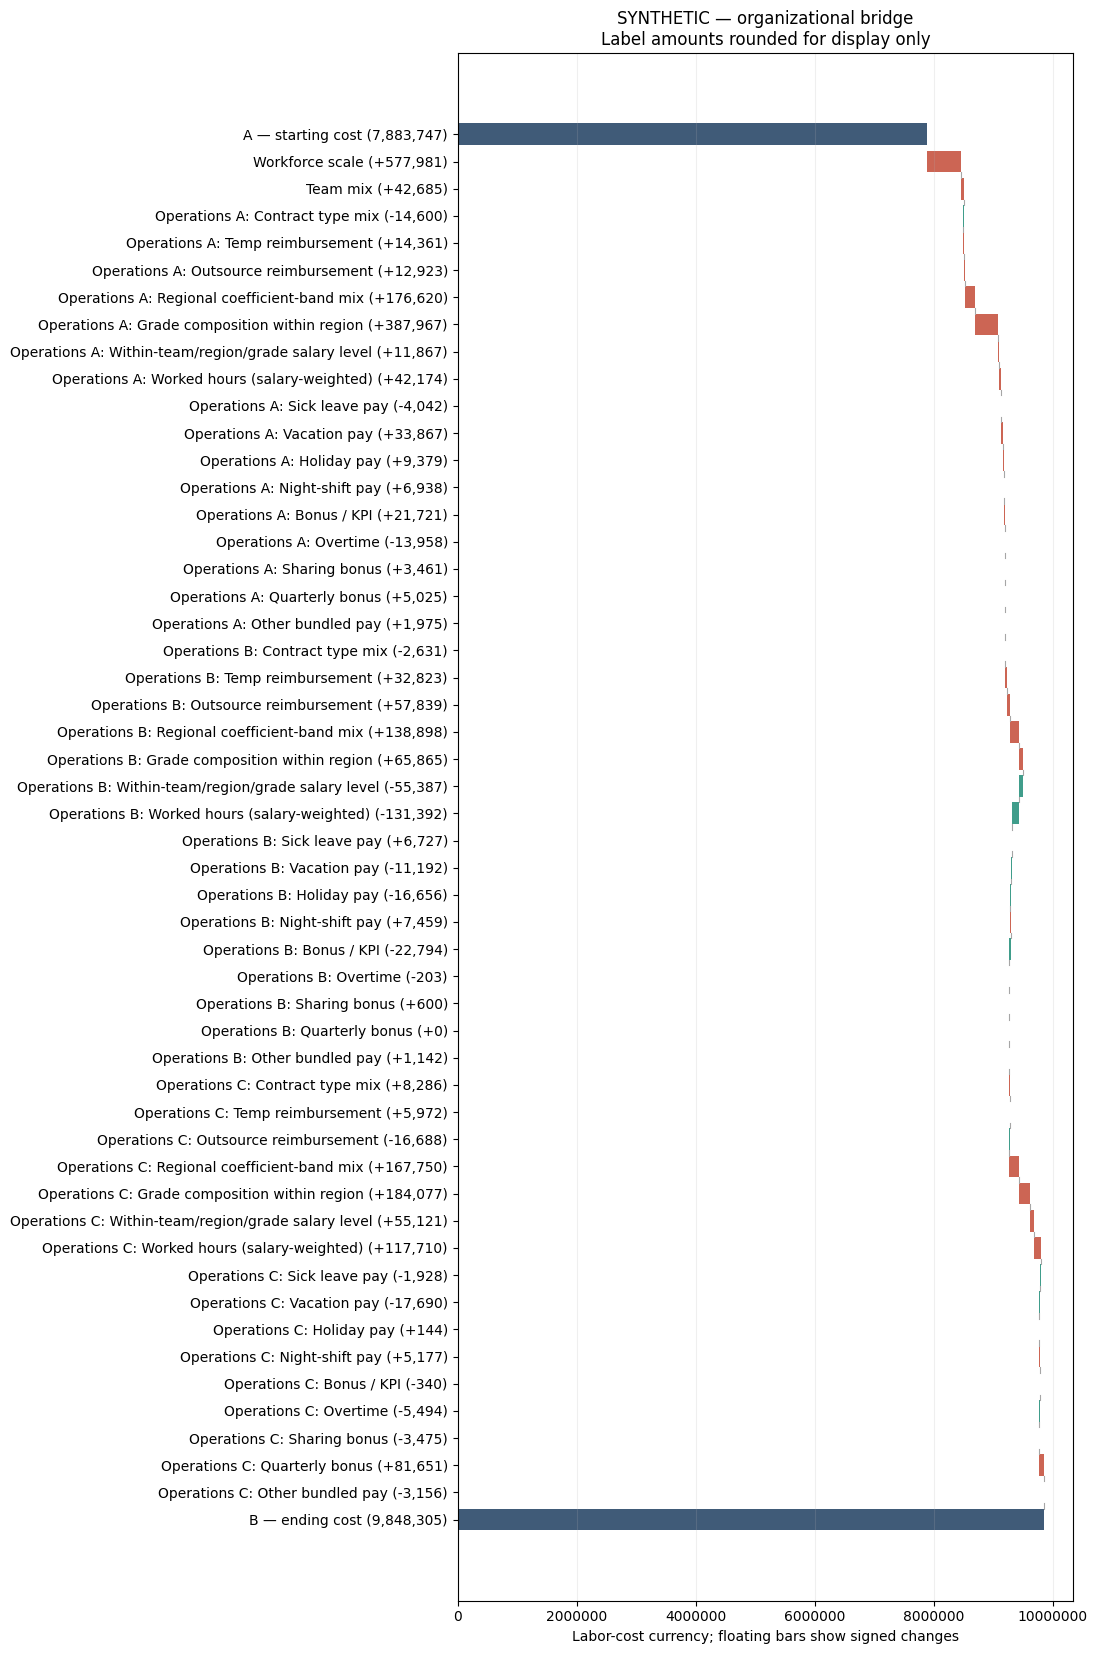

**SYNTHETIC — LOCAL Operations A**

,team,label,parent,level,impact,share_of_net_change
3,Operations A,Workforce scale,team_total,1,"390,879.633787",0.359632
22,Operations A,Contract type mix,team_economics,2,"-14,606.626619",-0.013439
23,Operations A,Temp reimbursement,team_economics,2,"14,368.064837",0.013219
24,Operations A,Outsource reimbursement,team_economics,2,"12,929.306663",0.011896
26,Operations A,Regional coefficient-band mix,permanent_unit_cost,3,"176,704.067333",0.162578
27,Operations A,Grade composition within region,permanent_unit_cost,3,"388,151.672487",0.357122
28,Operations A,Within-team/region/grade salary level,permanent_unit_cost,3,"11,872.418645",0.010923
29,Operations A,Worked hours (salary-weighted),permanent_unit_cost,3,"42,194.180550",0.038821
30,Operations A,Sick leave pay,permanent_unit_cost,3,"-4,043.902567",-0.003721
31,Operations A,Vacation pay,permanent_unit_cost,3,"33,883.280694",0.031175


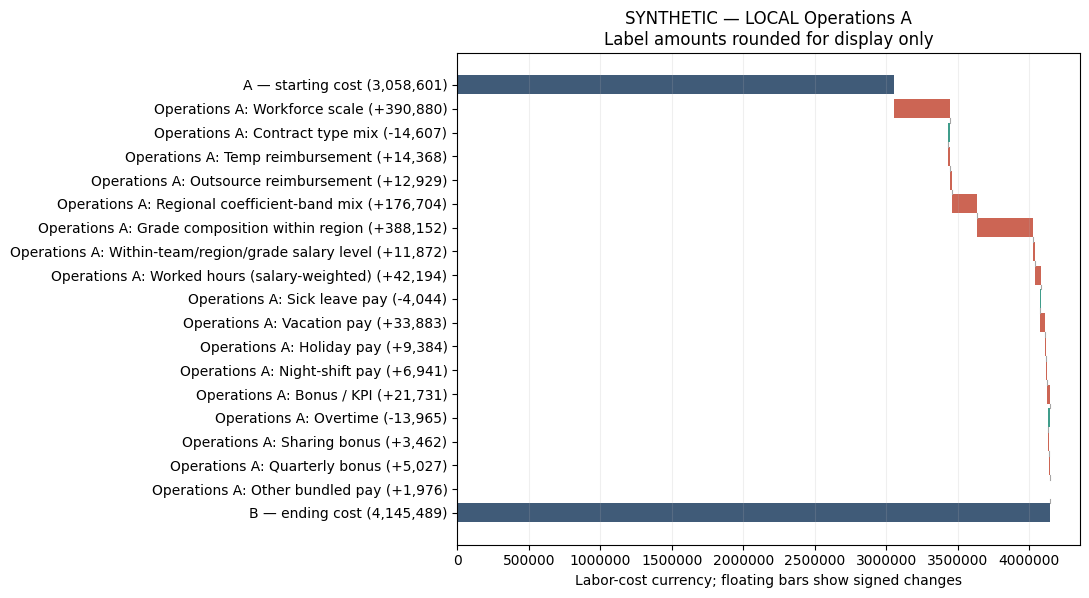

**SYNTHETIC — LOCAL Operations B**

,team,label,parent,level,impact,share_of_net_change
40,Operations B,Workforce scale,team_total,1,"-240,078.145708",1.419686
59,Operations B,Contract type mix,team_economics,2,"-2,626.637213",0.015532
60,Operations B,Temp reimbursement,team_economics,2,"32,764.963303",-0.193753
61,Operations B,Outsource reimbursement,team_economics,2,"57,736.636470",-0.341422
63,Operations B,Regional coefficient-band mix,permanent_unit_cost,3,"138,651.037196",-0.819903
64,Operations B,Grade composition within region,permanent_unit_cost,3,"65,747.573920",-0.388794
65,Operations B,Within-team/region/grade salary level,permanent_unit_cost,3,"-55,288.787540",0.326946
66,Operations B,Worked hours (salary-weighted),permanent_unit_cost,3,"-131,158.832422",0.775599
67,Operations B,Sick leave pay,permanent_unit_cost,3,"6,714.859820",-0.039708
68,Operations B,Vacation pay,permanent_unit_cost,3,"-11,171.778647",0.066064


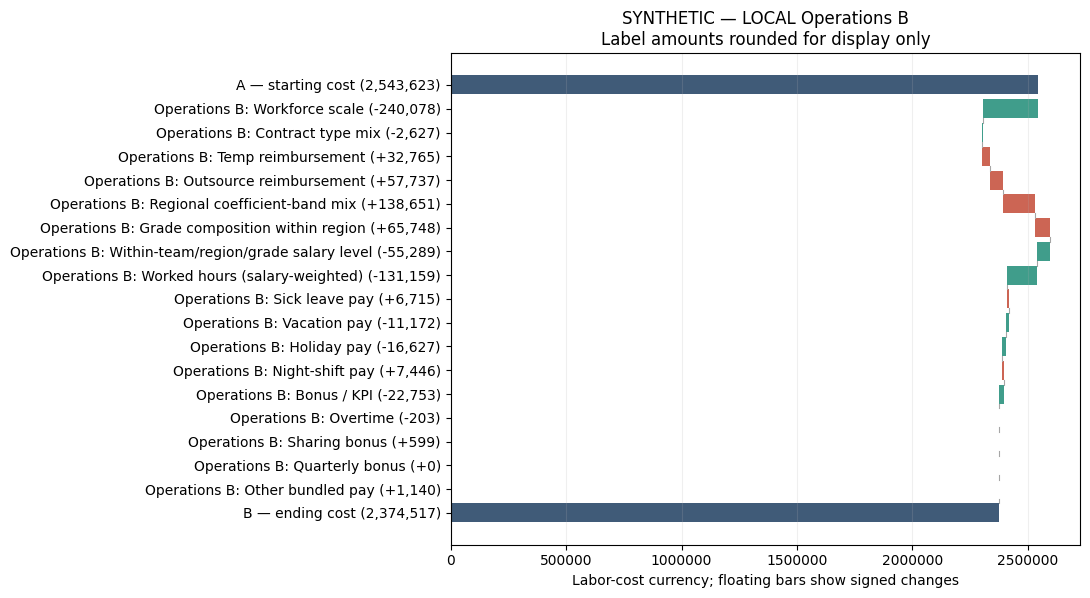

**SYNTHETIC — LOCAL Operations C**

,team,label,parent,level,impact,share_of_net_change
77,Operations C,Workforce scale,team_total,1,"469,007.911957",0.448050
96,Operations C,Contract type mix,team_economics,2,"8,295.653692",0.007925
97,Operations C,Temp reimbursement,team_economics,2,"5,978.527828",0.005711
98,Operations C,Outsource reimbursement,team_economics,2,"-16,706.657685",-0.015960
100,Operations C,Regional coefficient-band mix,permanent_unit_cost,3,"167,939.734640",0.160435
101,Operations C,Grade composition within region,permanent_unit_cost,3,"184,284.832311",0.176050
102,Operations C,Within-team/region/grade salary level,permanent_unit_cost,3,"55,182.839294",0.052717
103,Operations C,Worked hours (salary-weighted),permanent_unit_cost,3,"117,843.012065",0.112577
104,Operations C,Sick leave pay,permanent_unit_cost,3,"-1,930.296220",-0.001844
105,Operations C,Vacation pay,permanent_unit_cost,3,"-17,710.088902",-0.016919


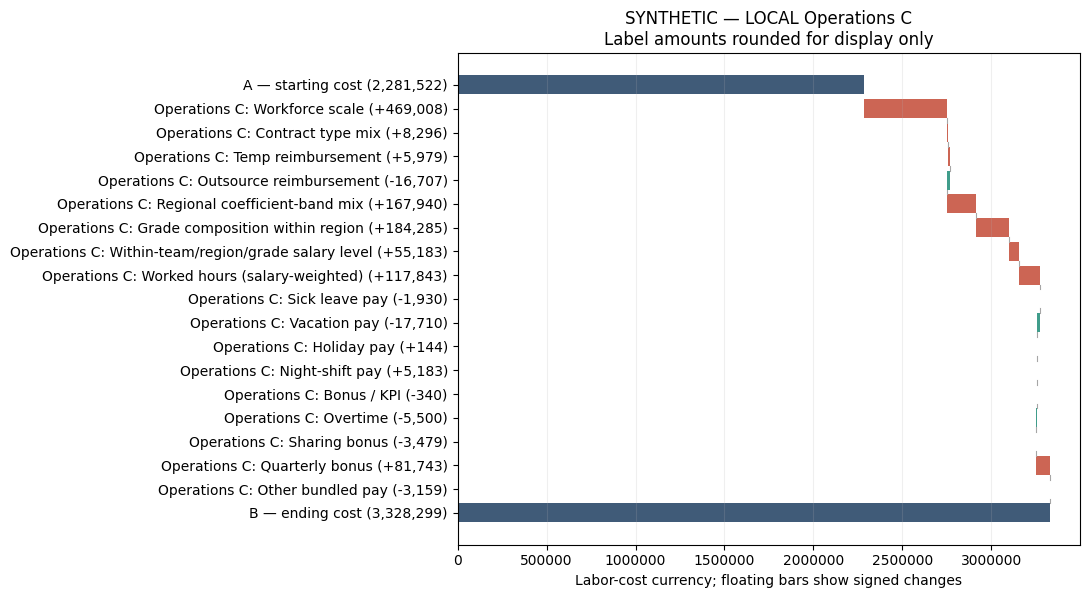

In [10]:
def waterfall(bridge,start,end,title):
    """Horizontal waterfall keeps long team/driver labels readable; includes A/B endpoints."""
    impacts = bridge.impact.to_numpy()
    running = np.r_[start,start+np.cumsum(impacts)]
    labels = [f'A — starting cost ({start:,.0f})'] + [
        (f'{r.team}: {r.label}' if r.team else r.label)+f' ({r.impact:+,.0f})'
        for r in bridge.itertuples()] + [f'B — ending cost ({end:,.0f})']
    fig,ax = plt.subplots(figsize=(11,max(4,.32*len(labels))))
    ax.barh(0,start,color='#405b78')
    for j,impact in enumerate(impacts,1):
        ax.barh(j,abs(impact),left=min(running[j-1],running[j]),color='#cc6554' if impact>=0 else '#409d8b')
        ax.plot([running[j],running[j]],[j+.4,j+.6],color='0.65',lw=.8)
    ax.barh(len(labels)-1,end,color='#405b78')
    ax.set_yticks(range(len(labels)),labels)
    ax.invert_yaxis()
    ax.set_xlabel('Labor-cost currency; floating bars show signed changes')
    ax.set_title(title+'\nLabel amounts rounded for display only')
    ax.ticklabel_format(style='plain',axis='x')
    ax.grid(axis='x',alpha=.2)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    return labels

def report(frame,a,b,result,registry=DRIVERS,*,plots=True):
    dataset = result['bridge'].dataset.iloc[0]
    show(dataset+' — reference basis',frame.groupby(['period','reference_basis'],dropna=False).source_cost.agg(['size','sum']))
    show(dataset+' — employee-month counts and exposure',frame.groupby(['period','team','contract_type']).agg(
        employee_months=('employee_id','size'),exposure=('exposure','sum')))
    summary = []
    for team,g in result['upper']['teams'].items():
        summary.append(dict(team=team,period_A_cost=g['local']['base'],period_B_cost=g['local']['end'],
            actual_team_change=g['local']['end']-g['local']['base'],
            organization_economics_impact=result['upper']['impacts']['team::'+team],
            local_bridge_error=result['local_bridges'][team].impact.sum()-(g['local']['end']-g['local']['base'])))
    show(dataset+' — team comparison (different views, do not add columns)',pd.DataFrame(summary))
    columns = ['team','label','parent','level','impact','share_of_net_change']
    show(dataset+' — organizational endpoints and error',pd.Series(dict(period_A_cost=cost(a,registry),period_B_cost=cost(b,registry),
        net_change=cost(b,registry)-cost(a,registry),bridge_error=result['bridge'].impact.sum()-(cost(b,registry)-cost(a,registry)))))
    with pd.option_context('display.max_rows',None):
        show(dataset+' — organizational flattened bridge',result['bridge'][columns])
    if plots:
        waterfall(result['bridge'],result['upper']['base'],result['upper']['end'],dataset+' — organizational bridge')
    for team,bridge in result['local_bridges'].items():
        with pd.option_context('display.max_rows',None):
            show(dataset+' — LOCAL '+team,bridge[columns])
        if plots:
            g=result['upper']['teams'][team]['local']
            waterfall(bridge,g['base'],g['end'],dataset+' — LOCAL '+team)

report(employees,state_A,state_B,result)


## 12. Diagnostics and validation

The salary driver is a **within-team/region/grade mean**, not a pay-raise estimate. Transfers, entries/exits,
and changing membership of the same cell can change it without individual raises. The cell audit below splits
the existing salary player's marginal using the **same coalition weights**, never creates employee/cell players,
and reconciles to the headline impact. Fallback support shares describe dependence on imputed cells, not uncertainty.
Matched IDs and team movements are separate descriptive evidence, never extra bridge lines.

The checks cover source/model totals, every hierarchy level and both views, all binary counterfactuals,
regional normalization, missing-support failures, transfers, symmetry, zero-change parents and extensibility.


In [11]:
def salary_cell_audit(pa,pb,game,coverage_a,coverage_b,fallback_a,fallback_b,team,M,K,L,registry=DRIVERS):
    names = [d.name for d in drivers_at(PARENT,registry)]
    key = 'underlying_salary_level'
    others = [name for name in names if name!=key]
    impacts = np.zeros_like(pa[key])
    for mask in product((0,1),repeat=len(others)):
        hybrid = dict(pa)
        hybrid.update({name:(pa,pb)[bit][name] for name,bit in zip(others,mask)})
        before = permanent_cell_costs(hybrid,registry)
        after = permanent_cell_costs(dict(hybrid,**{key:pb[key]}),registry)
        marginal = after-before
        # Shared cell-cost engine; the full switch is the difference of its summed costs.
        check('Salary marginal cell additivity',marginal.sum(),after.sum()-before.sum())
        k,n = sum(mask),len(names)
        impacts += factorial(k)*factorial(n-k-1)/factorial(n)*marginal
    check('Salary audit vs permanent SHAP',impacts.sum(),game['impacts'][key])
    index = pd.MultiIndex.from_product([pa['_policy']['regions'],pa['_policy']['grades']],names=['region','grade'])
    audit = index.to_frame(index=False).assign(team=team)
    for role,state,cov,fb in [('A',pa,coverage_a,fallback_a),('B',pb,coverage_b,fallback_b)]:
        counts = cov.loc[cov.team.eq(team)].set_index(['region','grade'])['count'].reindex(index)
        sources = fb.loc[fb.team.eq(team)&fb.variable.eq(key)].set_index(['region','grade']).fallback_level.reindex(index)
        sources = sources.where(counts.eq(0),'observed cell')
        if counts.isna().any() or sources.isna().any():
            raise ValueError('Missing salary support provenance')
        audit['count_'+role] = counts.to_numpy()
        audit['salary_'+role] = state[key].ravel()
        audit['source_'+role] = sources.to_numpy()
    audit['salary_change'] = audit.salary_B-audit.salary_A
    audit['unit_impact'] = impacts.ravel()
    audit['organization_impact'] = impacts.ravel()*M*K
    audit['local_impact'] = impacts.ravel()*L*K
    audit['support'] = np.where(audit.count_A.gt(0)&audit.count_B.gt(0),'observed in both','imputed in at least one')
    return audit

def matched_salary_diagnostic(frame,periods=(PERIOD_A,PERIOD_B)):
    cols = ['employee_id','team','region','grade','base_salary']
    p = frame.loc[frame.contract_type.eq('permanent')]
    a,b = [p.loc[p.period.eq(period),cols] for period in periods]
    matched = a.merge(b,on='employee_id',suffixes=('_A','_B'),validate='one_to_one')
    matched['salary_change'] = matched.base_salary_B-matched.base_salary_A
    for name in ('team','region','grade'):
        matched[name+'_changed'] = matched[name+'_A'].ne(matched[name+'_B'])
    matched['salary_changed'] = ~np.isclose(matched.base_salary_A.to_numpy(dtype=float),matched.base_salary_B.to_numpy(dtype=float),rtol=RTOL,atol=ATOL)
    all_a,all_b = [frame.loc[frame.period.eq(period)].set_index('employee_id') for period in periods]
    movements = []
    for team in sorted(frame.team.unique()):
        ids_a = set(all_a.index[all_a.team.eq(team)])
        ids_b = set(all_b.index[all_b.team.eq(team)])
        for event,ids,other in [('entered team sample',ids_b-ids_a,all_a),('left team sample',ids_a-ids_b,all_b)]:
            for eid in sorted(ids):
                exists = eid in other.index
                movements.append(dict(team=team,employee_id=eid,event=event,
                    organization_sample_event='present in both periods' if exists else ('entered organization sample' if event.startswith('entered') else 'left organization sample'),
                    other_period_team=other.loc[eid,'team'] if exists else None))
    summary = pd.Series(dict(matched_permanent_employees=len(matched),
        unchanged_base_salary=int((~matched.salary_changed).sum()),
        higher_base_salary=int((matched.salary_changed & matched.salary_change.gt(0)).sum()),
        lower_base_salary=int((matched.salary_changed & matched.salary_change.lt(0)).sum()),
        team_transfers=int(matched.team_changed.sum()),changed_region=int(matched.region_changed.sum()),
        changed_grade=int(matched.grade_changed.sum()),entered_permanent_sample=len(set(b.employee_id)-set(a.employee_id)),
        left_permanent_sample=len(set(a.employee_id)-set(b.employee_id))))
    return dict(summary=summary,matched=matched,movements=pd.DataFrame(movements),
                entrants=b.loc[~b.employee_id.isin(a.employee_id)],leavers=a.loc[~a.employee_id.isin(b.employee_id)])

def unsupported_mass(a,b,coverage_a,coverage_b,registry=DRIVERS):
    rows=[]
    for i,team in enumerate(a['_teams']):
        pa,pb = [s['teams'][team]['permanent'] for s in (a,b)]
        shape=pa['grade_mix_within_region'].shape
        max_exposure=max(a['workforce_scale'],b['workforce_scale'])*max(a['team_mix'][i],b['team_mix'][i])*max(
            a['teams'][team]['contract_type_mix'][0],b['teams'][team]['contract_type_mix'][0])
        for role,coverage in [('A',coverage_a),('B',coverage_b)]:
            missing=coverage.loc[coverage.team.eq(team),'count'].to_numpy().reshape(shape)==0
            mass=max(float(((pa,pb)[r]['regional_mix'][:,None]*(pa,pb)[g]['grade_mix_within_region'])[missing].sum())
                     for r,g in product((0,1),repeat=2))
            for d in drivers_at(PARENT,registry):
                if d.kind.startswith('cell_'):
                    rows.append(dict(team=team,value_period=role,variable=d.name,unsupported_cells=int(missing.sum()),
                        max_counterfactual_permanent_share=mass,max_counterfactual_permanent_exposure=mass*max_exposure))
    return pd.DataFrame(rows)

def diagnostics(frame,a,b,result,fa,fb,ca,cb,registry=DRIVERS):
    audits=[]
    for team,g in result['upper']['teams'].items():
        audits.append(salary_cell_audit(a['teams'][team]['permanent'],b['teams'][team]['permanent'],
            result['permanent'][team],ca,cb,fa,fb,team,g['M'],g['K'],g['L'],registry))
    salary=pd.concat(audits,ignore_index=True)
    support=[]
    for team,group in salary.groupby('team'):
        for view in ('organization','local'):
            col=view+'_impact'
            denominator,absolute=group[col].sum(),group[col].abs().sum()
            for name,part in group.groupby('support'):
                support.append(dict(team=team,view=view,support=name,cells=len(part),net_impact=part[col].sum(),
                    absolute_impact=part[col].abs().sum(),share_of_net=np.nan if abs(denominator)<=ATOL else part[col].sum()/denominator,
                    share_of_absolute=np.nan if absolute<=ATOL else part[col].abs().sum()/absolute))
    return dict(salary_cells=salary,salary_support=pd.DataFrame(support),matched=matched_salary_diagnostic(frame),
                coverage=pd.concat([ca,cb],ignore_index=True),fallbacks=pd.concat([fa,fb],ignore_index=True),
                unsupported=unsupported_mass(a,b,ca,cb,registry))

def reconcile_games(a,b,result,registry=DRIVERS):
    upper,permanent=result['upper'],result['permanent']
    checks=[check('organizational SHAP',upper['impacts'].sum(),cost(b,registry)-cost(a,registry)),
            check('organizational flattened bridge',result['bridge'].impact.sum(),cost(b,registry)-cost(a,registry))]
    local_changes=[]
    for i,team in enumerate(a['_teams']):
        g=upper['teams'][team]
        ua,ub=[team_units(s['teams'][team],registry) for s in (a,b)]
        checks += [check(team+' unit SHAP',g['unit']['impacts'].sum(),g['unit']['end']-g['unit']['base']),
            check(team+' permanent SHAP',permanent[team]['impacts'].sum(),ub[PARENT]-ua[PARENT]),
            check(team+' permanent parent',g['K']*permanent[team]['impacts'].sum(),g['unit']['impacts'][PARENT]),
            check(team+' organizational team parent',g['M']*g['unit']['impacts'].sum(),upper['impacts']['team::'+team]),
            check(team+' organizational permanent parent',g['M']*g['K']*permanent[team]['impacts'].sum(),g['M']*g['unit']['impacts'][PARENT]),
            check(team+' local economics parent',g['L']*g['unit']['impacts'].sum(),g['local']['impacts'][TEAM_PARENT]),
            check(team+' local permanent parent',g['L']*g['K']*permanent[team]['impacts'].sum(),g['L']*g['unit']['impacts'][PARENT]),
            check(team+' local bridge',result['local_bridges'][team].impact.sum(),g['local']['end']-g['local']['base'])]
        na,nb=a['workforce_scale'],b['workforce_scale']; qa,qb=a['team_mix'][i],b['team_mix'][i]
        checks += [check(team+' M analytical',g['M'],na*qa/3+(na*qb+nb*qa)/6+nb*qb/3),
                   check(team+' K analytical',g['K'],(ua['contract_type_mix'][0]+ub['contract_type_mix'][0])/2),
                   check(team+' L analytical',g['L'],(na*qa+nb*qb)/2)]
        # The dummy property must hold for every unchanged complete business driver.
        for d in drivers_at(PARENT,registry):
            if np.array_equal(a['teams'][team]['permanent'][d.name],b['teams'][team]['permanent'][d.name]):
                checks.append(check(team+' unchanged '+d.name,permanent[team]['impacts'][d.name],0))
        for d in drivers_at(TEAM_PARENT,registry):
            if np.array_equal(ua[d.name],ub[d.name]):
                checks.append(check(team+' unchanged '+d.name,g['unit']['impacts'][d.name],0))
        local_changes.append(g['local']['end']-g['local']['base'])
    checks.append(check('sum local endpoint changes',sum(local_changes),cost(b,registry)-cost(a,registry)))
    assert result['coalition_audit'].passed.all()
    return pd.DataFrame(checks)

def reconcile(frame,a,b,result,registry=DRIVERS,periods=(PERIOD_A,PERIOD_B)):
    checks=[]
    for period,state in zip(periods,(a,b)):
        rows=frame.loc[frame.period.eq(period)]
        checks.append(check(f'{period.date()} organization vs source',cost(state,registry),rows.source_cost.sum()))
        for i,team in enumerate(state['_teams']):
            n=state['workforce_scale']*state['team_mix'][i]
            costs=n*contract_cost_terms(team_units(state['teams'][team],registry),registry)
            team_rows=rows.loc[rows.team.eq(team)]
            checks.append(check(f'{period.date()} {team} vs source',costs.sum(),team_rows.source_cost.sum()))
            for contract,value in zip(CONTRACTS,costs):
                checks.append(check(f'{period.date()} {team} {contract} vs source',value,
                    team_rows.loc[team_rows.contract_type.eq(contract),'source_cost'].sum()))
    return pd.concat([pd.DataFrame(checks),reconcile_games(a,b,result,registry)],ignore_index=True)

def show_diagnostics(d, dataset):
    for name in ('salary_cells','salary_support','coverage','fallbacks','unsupported'):
        with pd.option_context('display.max_rows',None):
            show(dataset+' — '+name,d[name])
    show(dataset+' — matched permanent employee summary',d['matched']['summary'])
    show(dataset+' — matched permanent salary records (first 12)',d['matched']['matched'].head(12))
    show(dataset+' — team transfers among matched permanent IDs',d['matched']['matched'].loc[d['matched']['matched'].team_changed])
    show(dataset+' — observed team/organization sample movements',d['matched']['movements'])
    for name in ('entrants','leavers'):
        show(dataset+' — permanent sample '+name+' (first 12)',d['matched'][name].head(12))

validation=reconcile(employees,state_A,state_B,result)
base_diagnostics=diagnostics(employees,state_A,state_B,result,fallback_A,fallback_B,coverage_A,coverage_B)
result['diagnostics']=base_diagnostics
show('SYNTHETIC reconciliation — all checks',validation)
show('SYNTHETIC actual enumeration coverage and time',result['coalition_audit'])
show_diagnostics(base_diagnostics,'SYNTHETIC')
assert (base_diagnostics['coverage']['count']==0).any()
assert 'team_period_grade_distribution' in set(base_diagnostics['fallbacks'].fallback_level)
assert base_diagnostics['matched']['summary']['team_transfers']==3


**SYNTHETIC reconciliation — all checks**

,check,maximum_absolute_error,passed
0,2026-01-01 organization vs source,0.000000,True
1,2026-01-01 Operations A vs source,0.000000,True
2,2026-01-01 Operations A permanent vs source,0.000000,True
3,2026-01-01 Operations A temporary vs source,0.000000,True
4,2026-01-01 Operations A outsourced vs source,0.000000,True
...,...,...,...
58,Operations C local bridge,0.000000,True
59,Operations C M analytical,0.000000,True
60,Operations C K analytical,0.000000,True
61,Operations C L analytical,0.000000,True


**SYNTHETIC actual enumeration coverage and time**

,team,game,drivers,coalitions,minimum_cost,maximum_cost,seconds,passed
0,Operations A,permanent,13,8192,"59,429.556546","77,437.592216",4.385357,True
1,Operations B,permanent,13,8192,"49,592.116438","67,088.060675",1.125172,True
2,Operations C,permanent,13,8192,"60,099.331897","81,867.894516",1.122191,True
3,Operations A,unit,4,16,"58,483.295565","71,669.146221",0.001494,True
4,Operations A,organization_term,3,8,"3,058,601.277299","4,145,489.443929",0.000931,True
5,Operations A,local,2,4,"3,058,601.277299","4,145,489.443929",0.000743,True
6,Operations A,M_game,3,8,0.000000,58.000000,0.000969,True
7,Operations A,K_game,4,16,"14,167.327307","15,653.708796",0.001282,True
8,Operations A,L_game,2,4,0.000000,58.000000,0.000721,True
9,Operations B,unit,4,16,"58,409.372402","61,271.483249",0.001517,True


**SYNTHETIC — salary_cells**

...

,team,employee_id,event,organization_sample_event,other_period_team
0,Operations A,Operations A-outsourced-006,entered team sample,entered organization sample,None
1,Operations A,Operations A-outsourced-007,entered team sample,entered organization sample,None
2,Operations A,Operations A-permanent-038,entered team sample,entered organization sample,None
3,Operations A,Operations A-permanent-039,entered team sample,entered organization sample,None
4,Operations A,Operations A-permanent-040,entered team sample,entered organization sample,None
...,...,...,...,...,...
70,Operations C,Operations C-permanent-002,left team sample,left organization sample,None
71,Operations C,Operations C-permanent-004,left team sample,present in both periods,Operations A
72,Operations C,Operations C-temporary-000,left team sample,left organization sample,None
73,Operations C,Operations C-temporary-001,left team sample,left organization sample,None


**SYNTHETIC — permanent sample entrants (first 12)**

,employee_id,team,region,grade,base_salary
168,Operations A-permanent-038,Operations A,region_1.15,G3,"74,601.239974"
169,Operations A-permanent-039,Operations A,region_1.0,G2,"54,424.050065"
170,Operations A-permanent-040,Operations A,region_1.0,G2,"54,666.138490"
171,Operations A-permanent-041,Operations A,region_1.35,G3,"81,074.526336"
172,Operations A-permanent-042,Operations A,region_1.0,G1,"47,475.480255"
173,Operations A-permanent-043,Operations A,region_1.15,G2,"59,630.607906"
174,Operations A-permanent-044,Operations A,region_1.0,G2,"65,034.551336"
175,Operations A-permanent-045,Operations A,region_1.15,G1,"46,222.874175"
254,Operations C-permanent-027,Operations C,region_1.15,G1,"47,164.988081"
255,Operations C-permanent-028,Operations C,region_1.15,G1,"43,885.028672"


**SYNTHETIC — permanent sample leavers (first 12)**

,employee_id,team,region,grade,base_salary
0,Operations A-permanent-000,Operations A,region_1.15,G1,"47,848.223495"
1,Operations A-permanent-001,Operations A,region_1.15,G2,"67,058.097530"
2,Operations A-permanent-002,Operations A,region_1.15,G2,"59,072.533392"
52,Operations B-permanent-000,Operations B,region_1.15,G2,"65,351.213838"
53,Operations B-permanent-001,Operations B,region_1.0,G3,"84,280.498687"
54,Operations B-permanent-002,Operations B,region_1.15,G1,"45,178.222372"
79,Operations B-permanent-027,Operations B,region_1.15,G1,"38,294.926470"
80,Operations B-permanent-028,Operations B,region_1.15,G1,"44,562.279658"
81,Operations B-permanent-029,Operations B,region_1.0,G1,"44,253.393927"
95,Operations C-permanent-000,Operations C,region_1.15,G1,"44,887.009008"


### Counterfactual and regression checks

These small scenarios test the declared accounting semantics. Missing-economics tests use explicitly supplied
references only. Pure changes keep other state drivers fixed; they are not inferred employee-level interventions.


In [12]:
regression=[]

def expect_invalid(name,action):
    try:
        action()
    except (ValueError,KeyError,TypeError) as exc:
        regression.append(dict(check=name,maximum_absolute_error=0.0,passed=True,detail=str(exc)))
    else:
        raise AssertionError(f'{name}: invalid input was accepted')

def equal_states(a,b):
    if isinstance(a,dict):
        assert a.keys()==b.keys()
        for key in a:
            equal_states(a[key],b[key])
    elif isinstance(a,np.ndarray) or isinstance(a,(int,float,np.number)):
        check('Normalized state equality',a,b)
    else:
        assert a==b

def one_team(state,team):
    i=state['_teams'].index(team)
    return dict(workforce_scale=state['workforce_scale']*state['team_mix'][i],team_mix=np.ones(1),
                _teams=(team,),teams={team:deepcopy(state['teams'][team])})

def scenario(name,a,b):
    r=decompose(a,b,dataset=name)
    checks=reconcile_games(a,b,r)
    regression.append(dict(check=name,maximum_absolute_error=checks.maximum_absolute_error.max(),passed=True))
    return r

# A complete organizational game independently checks the additive term construction.
full_specs=tuple(d for d in drivers_at('total') if d.name!=TEAM_PARENT)+tuple(
    Driver('team::'+t,t+' economics','total') for t in state_A['_teams'])
def full_outer_state(s):
    return dict(workforce_scale=s['workforce_scale'],team_mix=s['team_mix'],
                **{'team::'+t:team_unit_cost(s['teams'][t]) for t in s['_teams']})
def full_outer_cost(s):
    return float(organization_cost_terms(s['workforce_scale'],s['team_mix'],
        [s['team::'+t] for t in state_A['_teams']]).sum())
full_outer=exact_game(full_outer_state(state_A),full_outer_state(state_B),full_specs,full_outer_cost)
regression.append(check('reduced outer = full organizational SHAP',full_outer['impacts'],result['upper']['impacts']))

team=TEAMS[0]
one_a,one_b=one_team(state_A,team),one_team(state_B,team)
one_result=scenario('single-team organization',one_a,one_b)
org=one_result['bridge'].set_index('driver').impact
local=one_result['local_bridges'][team].set_index('driver').impact
regression.append(check('single-team organizational = local hierarchy',org.loc[local.index],local))
regression.append(check('single-team mix impact',org['team_mix'],0))
identical=scenario('identical periods',one_a,deepcopy(one_a))
regression.append(check('identical periods: all leaves zero',identical['bridge'].impact,0))
assert identical['bridge'].share_of_net_change.isna().all()
reverse=scenario('reversed periods',one_b,one_a)
regression.append(check('reversed organizational leaf signs',reverse['bridge'].impact,-one_result['bridge'].impact))
regression.append(check('reversed local leaf signs',reverse['local_bridges'][team].impact,-one_result['local_bridges'][team].impact))

pure_mix=deepcopy(state_A); pure_mix['team_mix']=np.array([.2,.3,.5])
mix_result=scenario('pure team mix',state_A,pure_mix)
regression.append(check('pure team mix captures entire change',mix_result['upper']['impacts']['team_mix'],cost(pure_mix)-cost(state_A)))
regression.append(check('pure team mix leaves team economics unchanged',mix_result['bridge'].loc[mix_result['bridge'].team.notna(),'impact'],0))

# One-cell hand calculation: 2*(100*1.2 + 1+2+3+4+5+6) + 7+8+9 = 306.
hand=employees.loc[employees.period.eq(PERIOD_A)&employees.team.eq(team)].groupby('contract_type',sort=False).head(1).copy()
hand['team']='Hand example'; hand['period']=PERIOD_A
p=hand.contract_type.eq('permanent')
hand.loc[p,['region','grade']]=['region_2.0','G1']
hand.loc[p,'regional_coefficient']=2.0
hand.loc[p,'base_salary']=100.0; hand.loc[p,'worked_fraction']=1.2
for column,value in dict(sick_leave_pay=1,vacation_pay=2,holiday_pay=3,night_shift_pay=4,
                         sharing_bonus=5,quarterly_bonus=6,bonus_kpi=7,overtime_pay=8,other_pay=9).items():
    hand.loc[p,column]=float(value)
hand['source_cost']=employee_payroll_reference(hand)
hand_policy=make_policy(hand)
hand_state,_,_=build_state(hand,PERIOD_A,hand_policy)
regression.append(check('all eligible coefficients apply once: hand calculation',permanent_cost(hand_state['teams']['Hand example']['permanent']),306))
regression.append(check('hand source independent formula',hand.loc[p,'source_cost'].iloc[0],306))

# Same economics in both bands, different fixed coefficients; only regional composition changes.
region_a=deepcopy(hand_state)
rp=region_a['teams']['Hand example']['permanent']
rp['_policy']=dict(regions=('region_1.0','region_2.0'),grades=('G1',),regional_coefficients=np.array([1.,2.]))
for d in drivers_at(PARENT):
    rp[d.name]=np.repeat(rp[d.name],2,axis=0)
rp['regional_mix']=np.array([1.,0.])
region_b=deepcopy(region_a)
region_b['teams']['Hand example']['permanent']['regional_mix']=np.array([0.,1.])
region_result=scenario('pure regional composition across eligible components',region_a,region_b)
regression.append(check('regional change includes all eligible components',region_result['permanent']['Hand example']['impacts']['regional_mix'],141))
for d in drivers_at(PARENT):
    if d.cell_cost is not None and d.name!='underlying_salary_level':
        regression.append(check('unchanged payment '+d.name,region_result['permanent']['Hand example']['impacts'][d.name],0))

zero_a=deepcopy(one_a)
pa=zero_a['teams'][team]['permanent']
pa['holiday_pay'][:]=200; pa['sick_leave_pay'][:]=200
zero_b=deepcopy(zero_a)
zero_b['workforce_scale']+=7
zero_b['teams'][team]['permanent']['holiday_pay']+=75
zero_b['teams'][team]['permanent']['sick_leave_pay']-=75
zero_result=scenario('zero permanent parent with offsetting eligible payments',zero_a,zero_b)
payments=zero_result['bridge'].set_index('driver').impact
regression.append(check('offsetting permanent children cancel',payments['holiday_pay']+payments['sick_leave_pay'],0))
assert abs(payments['holiday_pay'])>ATOL
regression.append(check('zero permanent-unit change',permanent_cost(zero_b['teams'][team]['permanent'])-permanent_cost(zero_a['teams'][team]['permanent']),0))

unit_b=deepcopy(one_a)
ts=unit_b['teams'][team]
ts['temp_reimbursement']+=1000
ts['outsource_reimbursement']-=1000*ts['contract_type_mix'][1]/ts['contract_type_mix'][2]
unit_b['workforce_scale']+=5
unit_zero=scenario('zero team economics with offsetting contract rates',one_a,unit_b)
regression.append(check('zero economics parent',unit_zero['upper']['impacts']['team::'+team],0))
unit_leaves=unit_zero['bridge'].set_index('driver').impact
regression.append(check('offsetting team leaves cancel',unit_leaves['temp_reimbursement']+unit_leaves['outsource_reimbursement'],0))
assert abs(unit_leaves['temp_reimbursement'])>ATOL

# Normalization equality includes sparse fallback matrices and resulting Shapley impacts for every team.
eligible=tuple(col for d in drivers_at(PARENT) if d.apply_regional_coefficient for col in d.columns)
already_adjusted=employees.copy(); permanent_rows=already_adjusted.contract_type.eq('permanent')
for column in eligible:
    already_adjusted.loc[permanent_rows,column]*=already_adjusted.loc[permanent_rows,'regional_coefficient']
normalized=normalize_regional_inputs(already_adjusted,already_regionalized=eligible)
check('normalization never changes actual source_cost',normalized.source_cost,employees.source_cost)
na,nfa,nca=build_state(normalized,PERIOD_A,policy)
nb,nfb,ncb=build_state(normalized,PERIOD_B,policy)
equal_states(na,state_A); equal_states(nb,state_B)
for left,right in ((nfa,fallback_A),(nfb,fallback_B)):
    pd.testing.assert_frame_equal(left,right,check_exact=False,rtol=RTOL,atol=ATOL)
normalized_result=scenario('normalized regionalized sources including sparse fallbacks',na,nb)
regression.append(check('normalization: organizational impacts',normalized_result['bridge'].impact,result['bridge'].impact))
for t in TEAMS:
    regression.append(check('normalization: local '+t,normalized_result['local_bridges'][t].impact,result['local_bridges'][t].impact))

# Exposure is independent of worked time. Monetary inputs remain per exposure.
weighted=employees.copy(); weighted['exposure']=np.where(np.arange(len(weighted))%4==0,.5,1.)
weighted['source_cost']=employee_payroll_reference(weighted)
wa,wfa,wca=build_state(weighted,PERIOD_A,policy); wb,wfb,wcb=build_state(weighted,PERIOD_B,policy)
weighted_result=scenario('explicit fractional canonical exposure',wa,wb)
weighted_checks=reconcile(weighted,wa,wb,weighted_result)
regression.append(dict(check='fractional exposure source and contract reconciliation',maximum_absolute_error=weighted_checks.maximum_absolute_error.max(),passed=True))

# Fallback isolation: perturb another team's salary; this team's entire state must remain identical.
isolated=employees.copy(); isolated.loc[isolated.team.eq(TEAMS[1]),'base_salary']*=3
ia,ifa,ica=build_state(isolated,PERIOD_A,policy)
equal_states(ia['teams'][team],state_A['teams'][team])
regression.append(check('fallback isolation across teams',team_unit_cost(ia['teams'][team]),team_unit_cost(state_A['teams'][team])))
expect_invalid('unsupported cells with fallback disabled',lambda:build_state(employees,PERIOD_A,policy,fallback_order=()))

for contract,reference_key in [('temporary','temporary'),('outsourced','outsourced'),('permanent','permanent')]:
    reduced=employees.loc[~(employees.period.eq(PERIOD_A)&employees.team.eq(team)&employees.contract_type.eq(contract))].copy()
    expect_invalid('missing '+contract+' requires reference',lambda:build_state(reduced,PERIOD_A,policy))
    reference=(deepcopy(state_A['teams'][team]['permanent']) if contract=='permanent' else
               state_A['teams'][team]['temp_reimbursement' if contract=='temporary' else 'outsource_reimbursement'])
    rs,rf,rc=build_state(reduced,PERIOD_A,policy,references={(PERIOD_A,team):{reference_key:reference}})
    regression.append(check('explicit '+contract+' reference keeps observed endpoint',cost(rs),reduced.loc[reduced.period.eq(PERIOD_A),'source_cost'].sum()))
    assert 'business_reference' in set(rf.fallback_level)
    if contract=='permanent':
        referenced_result=scenario('missing permanent with complete reference',rs,state_B)
        referenced_diag=diagnostics(reduced,rs,state_B,referenced_result,rf,fallback_B,rc,coverage_B)
        assert not referenced_diag['salary_cells'].empty

absent=employees.loc[~(employees.period.eq(PERIOD_A)&employees.team.eq(team))].copy()
expect_invalid('absent team requires full reference',lambda:build_state(absent,PERIOD_A,policy))
referenced,ref_fa,ref_ca=build_state(absent,PERIOD_A,policy,references={(PERIOD_A,team):{'team_state':deepcopy(state_A['teams'][team])}})
reference_result=scenario('absent team with explicit economics',referenced,state_B)
reference_checks=reconcile(absent,referenced,state_B,reference_result)
regression.append(dict(check='absent-team source reconciliation',maximum_absolute_error=reference_checks.maximum_absolute_error.max(),passed=True))
assert 'business_reference' in set(ref_fa.fallback_level)

expect_invalid('duplicate employee-month even with different team',lambda:adapt_production(pd.concat([raw_synthetic,raw_synthetic.iloc[[0]].assign(lvl7_mapped_management_unit_nm='Other')])))
expect_invalid('missing team',lambda:adapt_production(raw_synthetic.assign(lvl7_mapped_management_unit_nm=None)))
expect_invalid('unknown production contract',lambda:adapt_production(raw_synthetic.assign(motivation_type='ГПХ')))
expect_invalid('invalid coefficient',lambda:adapt_production(raw_synthetic.assign(reg_coef=0.0)))
expect_invalid('missing required payment column',lambda:adapt_production(raw_synthetic.drop(columns='sum_pay_compacted')))
expect_invalid('missing applicable payment amount',lambda:adapt_production(raw_synthetic.assign(sum_pay_compacted=np.nan)))
expect_invalid('negative worked fraction',lambda:adapt_production(raw_synthetic.assign(vyrabotka_percent=-.1)))
expect_invalid('invalid reimbursement',lambda:adapt_production(raw_synthetic.assign(gpd_pay=np.nan)))
expect_invalid('unknown canonical contract',lambda:validate_input(employees.assign(contract_type='unknown')))
expect_invalid('normalizing ineligible component',lambda:normalize_regional_inputs(employees,already_regionalized=('overtime_pay',)))
expect_invalid('invalid exposure',lambda:validate_input(employees.assign(exposure=0.0)))
expect_invalid('missing required base salary',lambda:validate_input(employees.assign(base_salary=np.nan)))
expect_invalid('invalid fallback order',lambda:build_state(employees,PERIOD_A,policy,fallback_order=('other_team',)))
changed_policy=deepcopy(one_b); changed_policy['teams'][team]['permanent']['_policy']['regional_coefficients'][0]*=1.1
expect_invalid('differing A/B coefficient schedules',lambda:decompose(one_a,changed_policy))
wrong_grade=employees.copy(); wrong_grade.loc[wrong_grade.contract_type.eq('permanent'),'grade']='UNKNOWN'
expect_invalid('unknown grade outside aligned policy',lambda:build_state(wrong_grade,PERIOD_A,policy))
wrong_region=employees.copy(); wrong_region.loc[wrong_region.contract_type.eq('permanent'),'region']='UNKNOWN'
expect_invalid('unknown region outside aligned policy',lambda:build_state(wrong_region,PERIOD_A,policy))
for kind in ('team_mix','contract_type_mix','regional_mix','grade_mix_within_region'):
    invalid=deepcopy(one_a)
    target=invalid if kind=='team_mix' else (invalid['teams'][team] if kind=='contract_type_mix' else invalid['teams'][team]['permanent'])
    target[kind]=np.zeros_like(target[kind])
    expect_invalid('unnormalized '+kind,lambda:cost(invalid))
    target[kind].flat[0]=np.nan
    expect_invalid('nonfinite '+kind,lambda:cost(invalid))
    target[kind].flat[0]=-1
    expect_invalid('negative '+kind,lambda:cost(invalid))
expect_invalid('exact driver limit',lambda:exact_game({}, {}, [Driver(str(i),str(i),'x') for i in range(15)],lambda s:0))

reconstructed=adapt_production(raw_synthetic)
regression.append(check('production reconstructed vs independently generated reference',reconstructed.source_cost,employees.source_cost))
assert set(reconstructed.loc[reconstructed.contract_type.eq('permanent'),'reference_basis'])=={'reconstructed permanent payroll'}
regression_table=pd.DataFrame(regression)
with pd.option_context('display.max_rows',None):
    show('Counterfactual/invalid-input regression checks',regression_table)
assert regression_table.passed.all()


**Counterfactual/invalid-input regression checks**

,check,maximum_absolute_error,passed,detail
0,reduced outer = full organizational SHAP,0.000000,True,NaN
1,single-team organization,0.000000,True,NaN
2,single-team organizational = local hierarchy,0.000000,True,NaN
3,single-team mix impact,0.000000,True,NaN
4,identical periods,0.000000,True,NaN
5,identical periods: all leaves zero,0.000000,True,NaN
6,reversed periods,0.000000,True,NaN
7,reversed organizational leaf signs,0.000000,True,NaN
8,reversed local leaf signs,0.000000,True,NaN
9,pure team mix,0.000000,True,NaN


<a id="legacy-mock"></a>
### Legacy mock Jan–Feb results (optional CSV fixture)

This adapter alone handles the fixture's literal escaped `\r\n` line endings and decimal commas.
It uses one **Legacy mock workforce** team, exposure one, pre-regional base/sick/holiday pay, and utilization
as worked-time fraction. Legacy `ГПХ` maps to temporary; production uses `ГПД` instead.
Missing supplemental entries mean no recorded payment in this fixture. Vacation, night shift, sharing,
quarterly, other, KPI and overtime are explicitly unavailable and zero only for this narrower reconstruction.
No extra drivers are inferred from the CSV. Expected reconstructed totals remain **494,716.700** and **625,148.125**.


**MOCK reconciliation**

,check,maximum_absolute_error,passed
0,2026-01-01 organization vs source,0.000000,True
1,2026-01-01 Legacy mock workforce vs source,0.000000,True
2,2026-01-01 Legacy mock workforce permanent vs ...,0.000000,True
3,2026-01-01 Legacy mock workforce temporary vs ...,0.000000,True
4,2026-01-01 Legacy mock workforce outsourced vs...,0.000000,True
5,2026-02-01 organization vs source,0.000000,True
6,2026-02-01 Legacy mock workforce vs source,0.000000,True
7,2026-02-01 Legacy mock workforce permanent vs ...,0.000000,True
8,2026-02-01 Legacy mock workforce temporary vs ...,0.000000,True
9,2026-02-01 Legacy mock workforce outsourced vs...,0.000000,True


**MOCK — reconstructed payroll — reference basis**

,,size,sum
period,reference_basis,,
2026-01-01,legacy reconstructed payroll,13,"494,716.700000"
2026-02-01,legacy reconstructed payroll,16,"625,148.125000"


**MOCK — reconstructed payroll — employee-month counts and exposure**

...

,team,period_A_cost,period_B_cost,actual_team_change,organization_economics_impact,local_bridge_error
0,Legacy mock workforce,"494,716.700000","625,148.125000","130,431.425000","14,741.092127",0.000000


**MOCK — reconstructed payroll — organizational endpoints and error**

period_A_cost   494,716.700000
period_B_cost   625,148.125000
net_change      130,431.425000
bridge_error          0.000000
dtype: float64

**MOCK — reconstructed payroll — organizational flattened bridge**

,team,label,parent,level,impact,share_of_net_change
0,None,Workforce scale,total,1,"115,690.332873",0.886982
1,None,Team mix,total,1,-0.000000,-0.000000
5,Legacy mock workforce,Contract type mix,team_economics,2,"21,047.151713",0.161366
6,Legacy mock workforce,Temp reimbursement,team_economics,2,0.000000,0.000000
7,Legacy mock workforce,Outsource reimbursement,team_economics,2,0.000000,0.000000
9,Legacy mock workforce,Regional coefficient-band mix,permanent_unit_cost,3,"3,354.415506",0.025718
10,Legacy mock workforce,Grade composition within region,permanent_unit_cost,3,"-35,456.603848",-0.271841
11,Legacy mock workforce,Within-team/region/grade salary level,permanent_unit_cost,3,11.397905,0.000087
12,Legacy mock workforce,Worked hours (salary-weighted),permanent_unit_cost,3,"18,722.276675",0.143541
13,Legacy mock workforce,Sick leave pay,permanent_unit_cost,3,"-1,624.513977",-0.012455


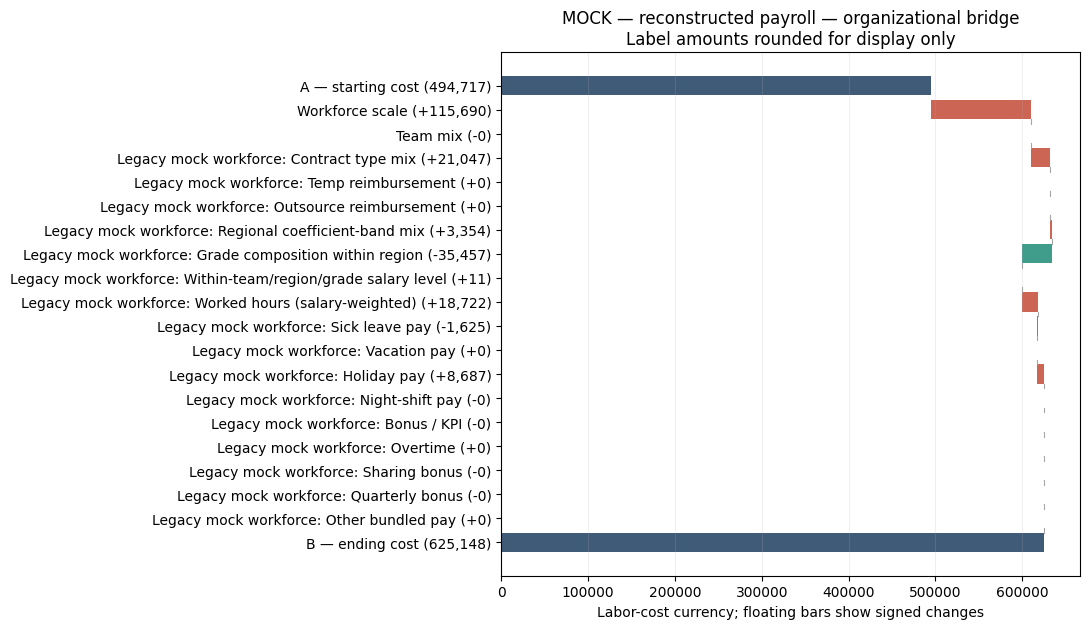

**MOCK — reconstructed payroll — LOCAL Legacy mock workforce**

,team,label,parent,level,impact,share_of_net_change
3,Legacy mock workforce,Workforce scale,team_total,1,"115,690.332873",0.886982
22,Legacy mock workforce,Contract type mix,team_economics,2,"21,047.151713",0.161366
23,Legacy mock workforce,Temp reimbursement,team_economics,2,0.000000,0.000000
24,Legacy mock workforce,Outsource reimbursement,team_economics,2,0.000000,0.000000
26,Legacy mock workforce,Regional coefficient-band mix,permanent_unit_cost,3,"3,354.415506",0.025718
27,Legacy mock workforce,Grade composition within region,permanent_unit_cost,3,"-35,456.603848",-0.271841
28,Legacy mock workforce,Within-team/region/grade salary level,permanent_unit_cost,3,11.397905,0.000087
29,Legacy mock workforce,Worked hours (salary-weighted),permanent_unit_cost,3,"18,722.276675",0.143541
30,Legacy mock workforce,Sick leave pay,permanent_unit_cost,3,"-1,624.513977",-0.012455
31,Legacy mock workforce,Vacation pay,permanent_unit_cost,3,0.000000,0.000000


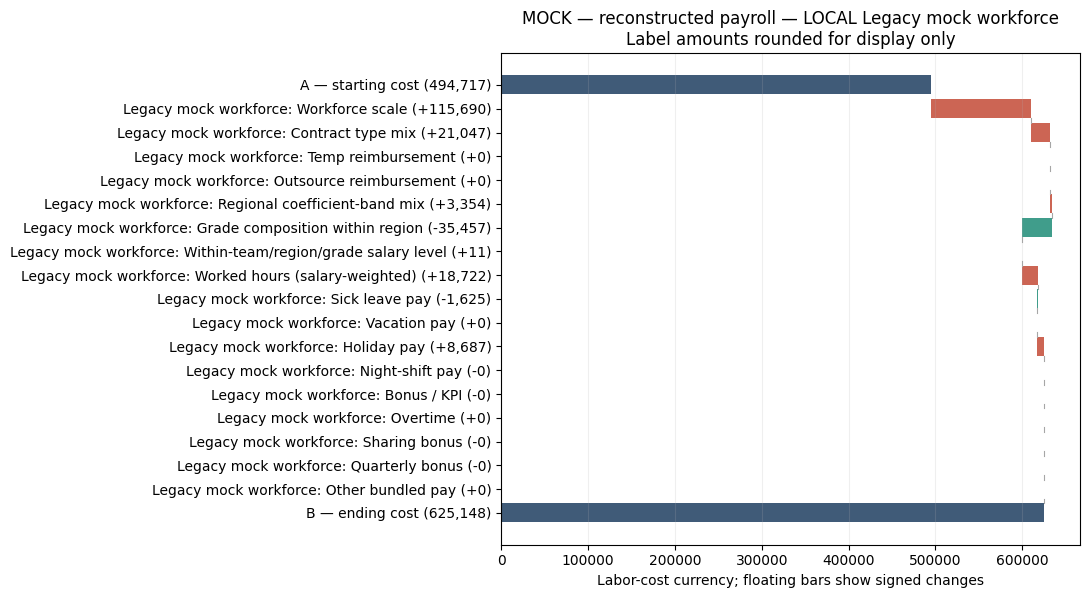

**MOCK — salary_cells**

,region,grade,team,count_A,salary_A,source_A,count_B,salary_B,source_B,salary_change,unit_impact,organization_impact,local_impact,support
0,region_0.75,G10,Legacy mock workforce,0,"45,000.000000",grade,1,"45,000.000000",observed cell,0.000000,0.000000,0.000000,0.000000,imputed in at least one
1,region_0.75,G11,Legacy mock workforce,0,"54,000.000000",grade,0,"53,000.000000",grade,"-1,000.000000",0.000000,0.000000,0.000000,imputed in at least one
2,region_0.75,G12,Legacy mock workforce,0,"63,750.000000",grade,2,"63,750.000000",observed cell,0.000000,0.000000,0.000000,0.000000,imputed in at least one
3,region_0.75,G13,Legacy mock workforce,2,"75,000.000000",observed cell,1,"75,000.000000",observed cell,0.000000,0.000000,0.000000,0.000000,observed in both
4,region_0.75,G9,Legacy mock workforce,1,"37,500.000000",observed cell,1,"37,500.000000",observed cell,0.000000,0.000000,0.000000,0.000000,observed in both
5,region_0.9,G10,Legacy mock workforce,1,"45,000.000000",observed cell,1,"45,000.000000",observed cell,0.000000,0.000000,0.000000,0.000000,observed in both
6,region_0.9,G11,Legacy mock workforce,2,"54,500.000000",observed cell,1,"53,000.000000",observed cell,"-1,500.000000",-137.980046,"-1,394.726185","-1,394.726185",observed in both
7,region_0.9,G12,Legacy mock workforce,0,"63,750.000000",grade,0,"63,750.000000",grade,0.000000,0.000000,0.000000,0.000000,imputed in at least one
8,region_0.9,G13,Legacy mock workforce,0,"75,000.000000",grade,0,"75,000.000000",grade,0.000000,0.000000,0.000000,0.000000,imputed in at least one
9,region_0.9,G9,Legacy mock workforce,0,"37,500.000000",grade,0,"37,500.000000",grade,0.000000,0.000000,0.000000,0.000000,imputed in at least one


**MOCK — salary_support**

,team,view,support,cells,net_impact,absolute_impact,share_of_net,share_of_absolute
0,Legacy mock workforce,organization,imputed in at least one,10,0.000000,0.000000,0.000000,0.000000
1,Legacy mock workforce,organization,observed in both,5,11.397905,"2,800.850275",1.000000,1.000000
2,Legacy mock workforce,local,imputed in at least one,10,0.000000,0.000000,0.000000,0.000000
3,Legacy mock workforce,local,observed in both,5,11.397905,"2,800.850275",1.000000,1.000000


**MOCK — coverage**

...

,employee_id,team,region,grade,base_salary
18,8de62e99-11c7-4ef1-b7b9-3e55288a9c4a,Legacy mock workforce,region_1.0,G10,"47,500.000000"
19,cb96fe87-d430-45ce-96d7-1f3f5c0d90ed,Legacy mock workforce,region_1.0,G10,"45,000.000000"
20,f0f2bcfd-bedc-4f29-be78-8603e09b2be4,Legacy mock workforce,region_0.75,G10,"45,000.000000"
21,8eed5d34-ab1d-450b-b109-9f89cca0f5a3,Legacy mock workforce,region_0.75,G12,"63,750.000000"
22,98dc7ae1-b785-4c6e-8a8b-3d186bc3cbee,Legacy mock workforce,region_0.75,G12,"63,750.000000"


**MOCK — permanent sample leavers (first 12)**

,employee_id,team,region,grade,base_salary
0,ba9b5679-225e-4f70-95e8-8808079620df,Legacy mock workforce,region_1.0,G9,"37,500.000000"
5,651c544c-3dfe-497a-b029-9d0ade3e781b,Legacy mock workforce,region_0.9,G11,"56,000.000000"
6,0ce7c103-2152-4e46-ac5e-925c9da80a43,Legacy mock workforce,region_1.0,G11,"53,000.000000"
7,e5143dff-4ee2-44ae-89a9-377b52d549d3,Legacy mock workforce,region_1.0,G12,"63,750.000000"
8,f628864b-40b5-40b0-88b7-6d96d237272e,Legacy mock workforce,region_0.75,G13,"75,000.000000"


**MOCK ordinary-means salary error**

,period,error
0,2026-01-01,-40.500000
1,2026-02-01,-91.666667


In [13]:
def adapt_mock(raw):
    mapping={'ТК':'permanent','ГПХ':'temporary','ПКЦ':'outsourced'}
    if not raw.contract_type.isin(mapping).all():
        raise ValueError('Unknown legacy contract')
    out=pd.DataFrame(dict(period=pd.to_datetime(raw.period),employee_id=raw.employee_id,
        team='Legacy mock workforce',contract_type=raw.contract_type.map(mapping),exposure=1.0))
    out['regional_coefficient']=pd.to_numeric(raw['regional coefficient'],errors='raise')
    out['region']=out.regional_coefficient.map(lambda x:band_name(x) if pd.notna(x) else None)
    out['grade']=raw.grade.map(lambda x:f'G{int(x)}' if pd.notna(x) else None)
    out['base_salary']=raw['base salary']; out['worked_fraction']=raw.capacity_utilization
    for column in PAYMENT_COLUMNS:
        out[column]=0.0  # Explicit fixture-only absence, not a production missing-value policy.
    out['holiday_pay']=raw['holiday pay'].fillna(0)
    out['sick_leave_pay']=raw['sick leave'].fillna(0)
    out['contract_reimbursement']=raw.contract_remuneration
    out['source_cost']=employee_payroll_reference(out)
    out['reference_basis']='legacy reconstructed payroll'
    validate_input(out)
    return out

mock_validation=pd.DataFrame()
mock_path=Path('costs_poc.csv')
if mock_path.exists():
    raw_mock=pd.read_csv(StringIO(mock_path.read_text().replace('\\r\\n','\n')),decimal=',')
    mock=adapt_mock(raw_mock)
    mock_policy=make_policy(mock)
    ma,mfa,mca=build_state(mock,PERIOD_A,mock_policy)
    mb,mfb,mcb=build_state(mock,PERIOD_B,mock_policy)
    check('legacy mock endpoints',[cost(ma),cost(mb)],[494716.700,625148.125])
    mock_result=decompose(ma,mb,dataset='MOCK — reconstructed payroll')
    mock_validation=reconcile(mock,ma,mb,mock_result)
    show('MOCK reconciliation',mock_validation)
    report(mock,ma,mb,mock_result)
    mock_diagnostics=diagnostics(mock,ma,mb,mock_result,mfa,mfb,mca,mcb)
    show_diagnostics(mock_diagnostics,'MOCK')
    assert mock_diagnostics['matched']['summary']['matched_permanent_employees']==5
    assert mock_diagnostics['matched']['summary']['higher_base_salary']==0
    assert mock_diagnostics['matched']['summary']['lower_base_salary']==0
    mt=ma['_teams'][0]
    ml=mock_result['local_bridges'][mt].set_index('driver').impact
    mo=mock_result['bridge'].set_index('driver').impact
    check('mock one-team view equivalence',mo.loc[ml.index],ml)
    errors=[]
    for period in (PERIOD_A,PERIOD_B):
        p=mock.loc[mock.period.eq(period)&mock.contract_type.eq('permanent')]
        naive=sum(r.exposure.sum()*r.regional_coefficient.iloc[0]*weighted_mean(r,r.base_salary)*weighted_mean(r,r.worked_fraction)
                  for _,r in p.groupby(['region','grade']))
        actual=(p.exposure*p.regional_coefficient*p.base_salary*p.worked_fraction).sum()
        errors.append(naive-actual)
    check('ordinary salary × time means miss payroll',errors,[-40.5,-91.6666666667])
    show('MOCK ordinary-means salary error',pd.DataFrame({'period':[PERIOD_A,PERIOD_B],'error':errors}))
else:
    print('Optional costs_poc.csv absent: all synthetic examples and validations still run.')


## 13. Add one new driver: regional transport allowance

Night-shift pay is now a standard component. This hypothetical extension requires exactly two localized changes:
**add the source payment/reference payroll**, and **register its builder and regional contribution**.
All subsequent builders, exact games, propagation, tables, diagnostics and plots use the existing functions.
There are now 14 permanent drivers (16,384 coalitions). No transport-specific branches are added to the pipeline.


**Extension registry**

,driver,label,parent,source_columns,validation,payroll_contribution,apply_regional_coefficient
20,transport_allowance,Transport allowance,permanent_unit_cost,transport_allowance,cell_nonnegative,True,True


**Extension reconciliation**

,check,maximum_absolute_error,passed
0,2026-01-01 organization vs source,0.000000,True
1,2026-01-01 Operations A vs source,0.000000,True
2,2026-01-01 Operations A permanent vs source,0.000000,True
3,2026-01-01 Operations A temporary vs source,0.000000,True
4,2026-01-01 Operations A outsourced vs source,0.000000,True
...,...,...,...
58,Operations C local bridge,0.000000,True
59,Operations C M analytical,0.000000,True
60,Operations C K analytical,0.000000,True
61,Operations C L analytical,0.000000,True


**Extension enumeration coverage**

...

,team,period_A_cost,period_B_cost,actual_team_change,organization_economics_impact,local_bridge_error
0,Operations A,"3,069,038.777299","4,188,116.943929","1,119,078.166630","725,045.818109",-0.000000
1,Operations B,"2,551,723.246872","2,397,551.710417","-154,171.536455","87,620.345100",0.000000
2,Operations C,"2,288,722.199743","3,360,641.620201","1,071,919.420458","599,056.776763",-0.000000


**SYNTHETIC + transport allowance — organizational endpoints and error**

period_A_cost   7,909,484.223914
period_B_cost   9,946,310.274547
net_change      2,036,826.050633
bridge_error           -0.000000
dtype: float64

**SYNTHETIC + transport allowance — organizational flattened bridge**

,team,label,parent,level,impact,share_of_net_change
0,None,Workforce scale,total,1,"581,948.084328",0.285713
1,None,Team mix,total,1,"43,155.026333",0.021187
5,Operations A,Contract type mix,team_economics,2,"-14,230.449627",-0.006987
6,Operations A,Temp reimbursement,team_economics,2,"14,361.217829",0.007051
7,Operations A,Outsource reimbursement,team_economics,2,"12,923.145286",0.006345
9,Operations A,Regional coefficient-band mix,permanent_unit_cost,3,"178,124.226736",0.087452
10,Operations A,Grade composition within region,permanent_unit_cost,3,"387,966.701342",0.190476
11,Operations A,Within-team/region/grade salary level,permanent_unit_cost,3,"11,866.760921",0.005826
12,Operations A,Worked hours (salary-weighted),permanent_unit_cost,3,"42,174.073189",0.020706
13,Operations A,Sick leave pay,permanent_unit_cost,3,"-4,041.975472",-0.001984


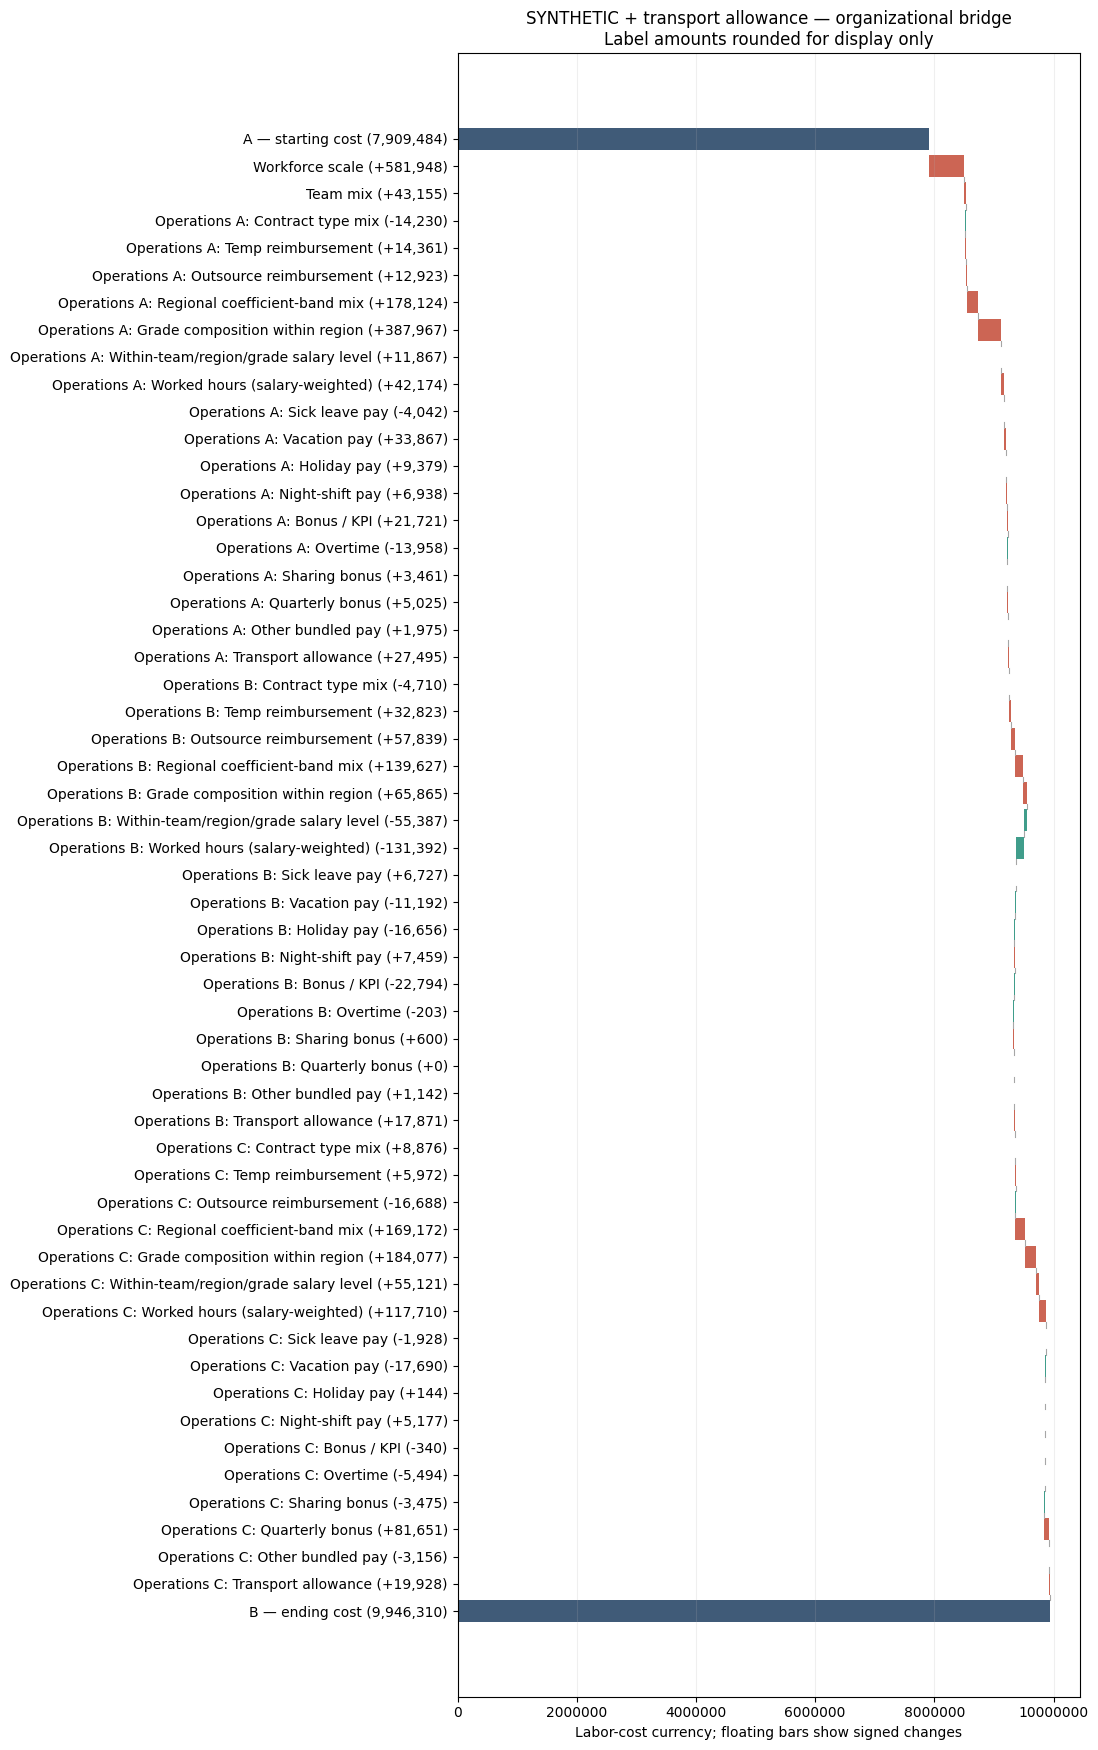

**SYNTHETIC + transport allowance — LOCAL Operations A**

,team,label,parent,level,impact,share_of_net_change
3,Operations A,Workforce scale,team_total,1,"393,686.667939",0.351796
23,Operations A,Contract type mix,team_economics,2,"-14,237.234288",-0.012722
24,Operations A,Temp reimbursement,team_economics,2,"14,368.064837",0.012839
25,Operations A,Outsource reimbursement,team_economics,2,"12,929.306663",0.011554
27,Operations A,Regional coefficient-band mix,permanent_unit_cost,3,"178,209.151144",0.159246
28,Operations A,Grade composition within region,permanent_unit_cost,3,"388,151.672487",0.346849
29,Operations A,Within-team/region/grade salary level,permanent_unit_cost,3,"11,872.418645",0.010609
30,Operations A,Worked hours (salary-weighted),permanent_unit_cost,3,"42,194.180550",0.037704
31,Operations A,Sick leave pay,permanent_unit_cost,3,"-4,043.902567",-0.003614
32,Operations A,Vacation pay,permanent_unit_cost,3,"33,883.280694",0.030278


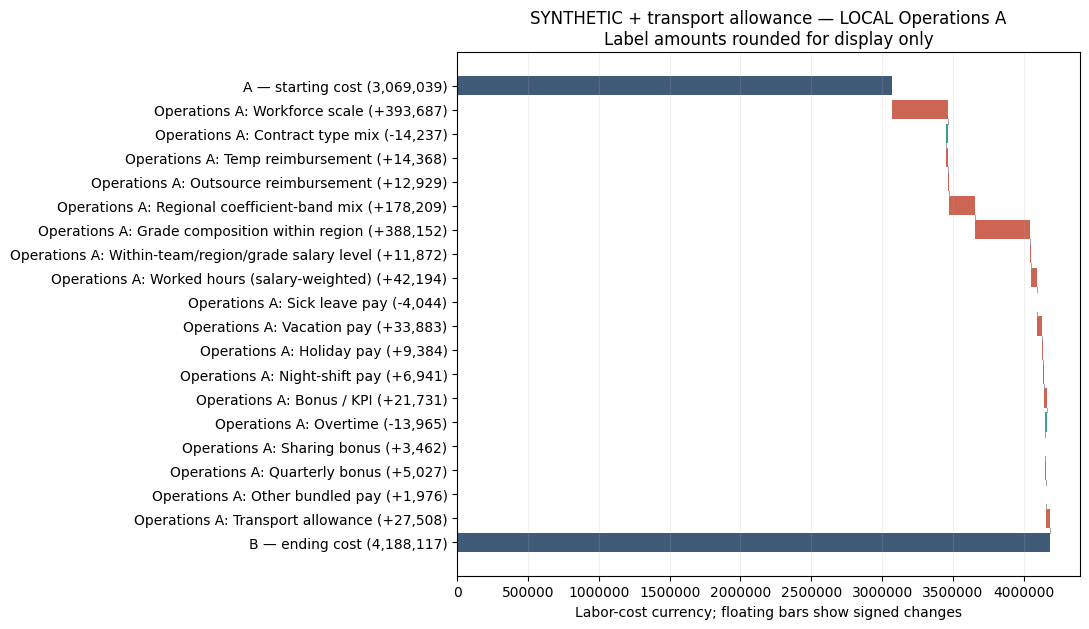

**SYNTHETIC + transport allowance — LOCAL Operations B**

,team,label,parent,level,impact,share_of_net_change
42,Operations B,Workforce scale,team_total,1,"-241,636.171945",1.567320
62,Operations B,Contract type mix,team_economics,2,"-4,701.223155",0.030493
63,Operations B,Temp reimbursement,team_economics,2,"32,764.963303",-0.212523
64,Operations B,Outsource reimbursement,team_economics,2,"57,736.636470",-0.374496
66,Operations B,Regional coefficient-band mix,permanent_unit_cost,3,"139,378.936943",-0.904051
67,Operations B,Grade composition within region,permanent_unit_cost,3,"65,747.573920",-0.426457
68,Operations B,Within-team/region/grade salary level,permanent_unit_cost,3,"-55,288.787540",0.358619
69,Operations B,Worked hours (salary-weighted),permanent_unit_cost,3,"-131,158.832422",0.850733
70,Operations B,Sick leave pay,permanent_unit_cost,3,"6,714.859820",-0.043554
71,Operations B,Vacation pay,permanent_unit_cost,3,"-11,171.778647",0.072463


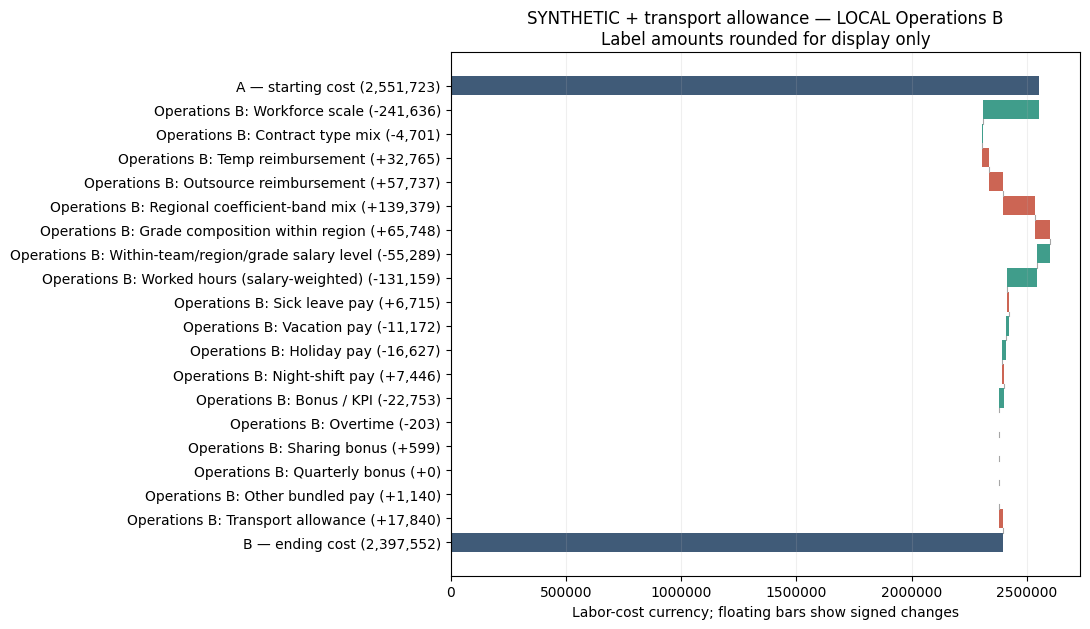

**SYNTHETIC + transport allowance — LOCAL Operations C**

,team,label,parent,level,impact,share_of_net_change
81,Operations C,Workforce scale,team_total,1,"472,186.597629",0.440506
101,Operations C,Contract type mix,team_economics,2,"8,885.669076",0.008289
102,Operations C,Temp reimbursement,team_economics,2,"5,978.527828",0.005577
103,Operations C,Outsource reimbursement,team_economics,2,"-16,706.657685",-0.015586
105,Operations C,Regional coefficient-band mix,permanent_unit_cost,3,"169,362.838806",0.158000
106,Operations C,Grade composition within region,permanent_unit_cost,3,"184,284.832311",0.171920
107,Operations C,Within-team/region/grade salary level,permanent_unit_cost,3,"55,182.839294",0.051480
108,Operations C,Worked hours (salary-weighted),permanent_unit_cost,3,"117,843.012065",0.109936
109,Operations C,Sick leave pay,permanent_unit_cost,3,"-1,930.296220",-0.001801
110,Operations C,Vacation pay,permanent_unit_cost,3,"-17,710.088902",-0.016522


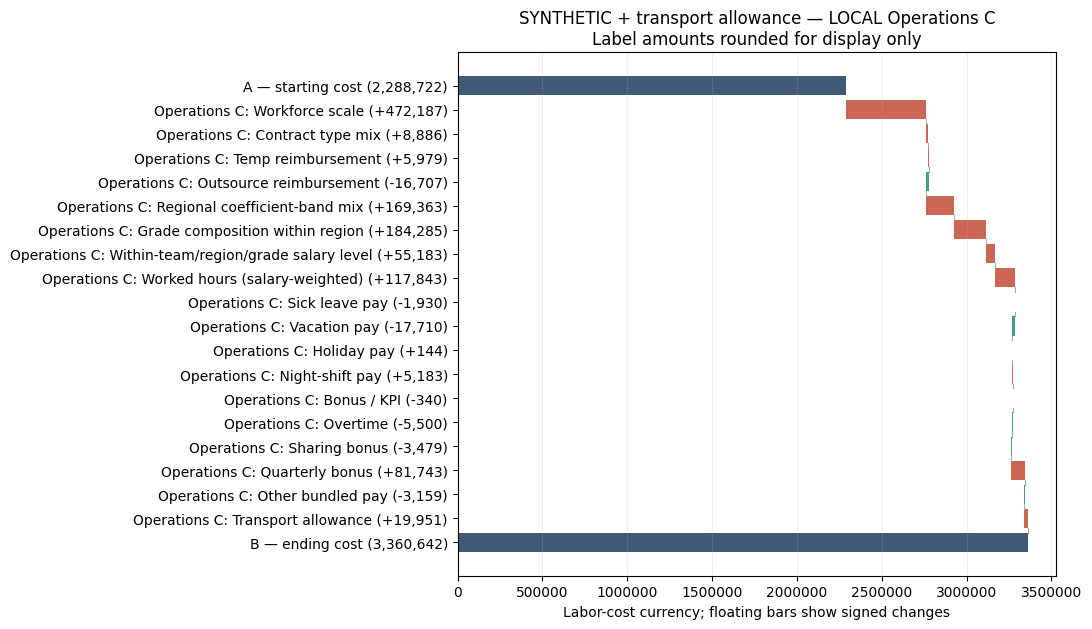

**SYNTHETIC + transport allowance — salary_cells**

,region,grade,team,count_A,salary_A,source_A,count_B,salary_B,source_B,salary_change,unit_impact,organization_impact,local_impact,support
0,region_1.0,G1,Operations A,5,"44,171.545548",observed cell,4,"44,259.102884",observed cell,87.557336,8.566835,346.655201,346.820476,observed in both
1,region_1.0,G2,Operations A,7,"56,941.398873",observed cell,6,"58,625.250631",observed cell,"1,683.851758",233.921345,"9,465.578658","9,470.091568",observed in both
2,region_1.0,G3,Operations A,1,"92,365.894659",observed cell,0,"88,215.406880",grade,"-4,150.487779",-43.328772,"-1,753.289764","-1,754.125681",imputed in at least one
3,region_1.15,G1,Operations A,10,"42,987.234015",observed cell,7,"42,579.282727",observed cell,-407.951288,-85.429409,"-3,456.883314","-3,458.531454",observed in both
4,region_1.15,G2,Operations A,15,"60,190.783774",observed cell,6,"60,993.860946",observed cell,803.077173,209.201856,"8,465.309697","8,469.345708",observed in both
5,region_1.15,G3,Operations A,0,"92,365.894659",grade,9,"90,122.133441",observed cell,"-2,243.761218",-265.763886,"-10,754.080501","-10,759.207732",imputed in at least one
6,region_1.35,G1,Operations A,0,"43,382.004526",grade,5,"47,129.909020",observed cell,"3,747.904494",253.232491,"10,247.000209","10,251.885679",imputed in at least one
7,region_1.35,G2,Operations A,0,"59,156.888578",grade,2,"65,508.524229",observed cell,"6,351.635651",305.695141,"12,369.890435","12,375.788036",imputed in at least one
8,region_1.35,G3,Operations A,0,"92,365.894659",grade,4,"83,925.272120",observed cell,"-8,440.622539",-322.834220,"-13,063.419699","-13,069.647955",imputed in at least one
9,region_1.0,G1,Operations B,4,"44,591.158227",observed cell,5,"43,164.064847",observed cell,"-1,427.093380",-213.939297,"-5,769.008065","-5,758.755994",observed in both


**SYNTHETIC + transport allowance — salary_support**

,team,view,support,cells,net_impact,absolute_impact,share_of_net,share_of_absolute
0,Operations A,organization,imputed in at least one,5,"-2,953.899320","48,187.680608",-0.248922,0.689162
1,Operations A,organization,observed in both,4,"14,820.660242","21,734.426870",1.248922,0.310838
2,Operations A,local,imputed in at least one,5,"-2,955.307653","48,210.655081",-0.248922,0.689162
3,Operations A,local,observed in both,4,"14,827.726298","21,744.789207",1.248922,0.310838
4,Operations B,organization,imputed in at least one,4,"7,651.826003","7,651.826003",-0.138151,0.073791
5,Operations B,organization,observed in both,5,"-63,039.041845","96,043.599342",1.138151,0.926209
6,Operations B,local,imputed in at least one,4,"7,638.227987","7,638.227987",-0.138151,0.073791
7,Operations B,local,observed in both,5,"-62,927.015526","95,872.920815",1.138151,0.926209
8,Operations C,organization,imputed in at least one,4,"5,419.036430","29,509.273722",0.098312,0.282035
9,Operations C,organization,observed in both,5,"49,701.598262","75,120.709661",0.901688,0.717965


**SYNTHETIC + transport allowance — coverage**

...

,team,employee_id,event,organization_sample_event,other_period_team
0,Operations A,Operations A-outsourced-006,entered team sample,entered organization sample,None
1,Operations A,Operations A-outsourced-007,entered team sample,entered organization sample,None
2,Operations A,Operations A-permanent-038,entered team sample,entered organization sample,None
3,Operations A,Operations A-permanent-039,entered team sample,entered organization sample,None
4,Operations A,Operations A-permanent-040,entered team sample,entered organization sample,None
...,...,...,...,...,...
70,Operations C,Operations C-permanent-002,left team sample,left organization sample,None
71,Operations C,Operations C-permanent-004,left team sample,present in both periods,Operations A
72,Operations C,Operations C-temporary-000,left team sample,left organization sample,None
73,Operations C,Operations C-temporary-001,left team sample,left organization sample,None


**SYNTHETIC + transport allowance — permanent sample entrants (first 12)**

,employee_id,team,region,grade,base_salary
168,Operations A-permanent-038,Operations A,region_1.15,G3,"74,601.239974"
169,Operations A-permanent-039,Operations A,region_1.0,G2,"54,424.050065"
170,Operations A-permanent-040,Operations A,region_1.0,G2,"54,666.138490"
171,Operations A-permanent-041,Operations A,region_1.35,G3,"81,074.526336"
172,Operations A-permanent-042,Operations A,region_1.0,G1,"47,475.480255"
173,Operations A-permanent-043,Operations A,region_1.15,G2,"59,630.607906"
174,Operations A-permanent-044,Operations A,region_1.0,G2,"65,034.551336"
175,Operations A-permanent-045,Operations A,region_1.15,G1,"46,222.874175"
254,Operations C-permanent-027,Operations C,region_1.15,G1,"47,164.988081"
255,Operations C-permanent-028,Operations C,region_1.15,G1,"43,885.028672"


**SYNTHETIC + transport allowance — permanent sample leavers (first 12)**

,employee_id,team,region,grade,base_salary
0,Operations A-permanent-000,Operations A,region_1.15,G1,"47,848.223495"
1,Operations A-permanent-001,Operations A,region_1.15,G2,"67,058.097530"
2,Operations A-permanent-002,Operations A,region_1.15,G2,"59,072.533392"
52,Operations B-permanent-000,Operations B,region_1.15,G2,"65,351.213838"
53,Operations B-permanent-001,Operations B,region_1.0,G3,"84,280.498687"
54,Operations B-permanent-002,Operations B,region_1.15,G1,"45,178.222372"
79,Operations B-permanent-027,Operations B,region_1.15,G1,"38,294.926470"
80,Operations B-permanent-028,Operations B,region_1.15,G1,"44,562.279658"
81,Operations B-permanent-029,Operations B,region_1.0,G1,"44,253.393927"
95,Operations C-permanent-000,Operations C,region_1.15,G1,"44,887.009008"


In [14]:
# Change 1: synthetic source-data/payroll addition, independently calculated per employee.
extended=employees.copy()
p=extended.contract_type.eq('permanent')
extended['transport_allowance']=np.where(p,np.where(extended.period.eq(PERIOD_A),250.0,850.0),0.0)
extended.loc[p,'source_cost']+=extended.loc[p,'exposure']*extended.loc[p,'regional_coefficient']*extended.loc[p,'transport_allowance']
extended['reference_basis']='independent synthetic payroll + transport allowance'

# Change 2: one registration containing builder, validation, contribution and regional eligibility.
extended_registry=DRIVERS+(payment_driver('transport_allowance','Transport allowance','transport_allowance',apply_regional_coefficient=True),)

# The existing pipeline, unchanged.
ea,efa,eca=build_state(extended,PERIOD_A,policy,extended_registry)
eb,efb,ecb=build_state(extended,PERIOD_B,policy,extended_registry)
extended_result=decompose(ea,eb,extended_registry,dataset='SYNTHETIC + transport allowance')
extended_validation=reconcile(extended,ea,eb,extended_result,extended_registry)
extended_diagnostics=diagnostics(extended,ea,eb,extended_result,efa,efb,eca,ecb,extended_registry)
show('Extension registry',registry_table(extended_registry).tail(1))
show('Extension reconciliation',extended_validation)
show('Extension enumeration coverage',extended_result['coalition_audit'])
report(extended,ea,eb,extended_result,registry=extended_registry)
show_diagnostics(extended_diagnostics,'SYNTHETIC + transport allowance')
assert len(drivers_at(PARENT,extended_registry))==14
assert extended_result['bridge'].driver.eq('transport_allowance').sum()==len(TEAMS)
assert 'transport_allowance' in set(extended_diagnostics['fallbacks'].variable)
assert 'transport_allowance' in set(extended_diagnostics['unsupported'].variable)
for t in TEAMS:
    assert 'transport_allowance' in extended_result['permanent'][t]['impacts'].index
    assert extended_result['local_bridges'][t].driver.eq('transport_allowance').any()
    assert extended_result['permanent'][t]['audit']['coalitions']==2**14
    leaf=extended_result['bridge'].loc[extended_result['bridge'].team.eq(t)&extended_result['bridge'].driver.eq('transport_allowance'),'impact'].iloc[0]
    g=extended_result['upper']['teams'][t]
    check('automatic transport propagation',leaf,g['M']*g['K']*extended_result['permanent'][t]['impacts']['transport_allowance'])


## 14. Future planning and final review

A planner can construct a valid state directly, choose total workforce size, team shares, and each team's
contract, region, and conditional-grade mixes, then call `cost(state)`. Distribution constraints, staffing minima,
service capacity, available skills, hiring limits and contract policies would constrain those choices. Salary,
payment and reimbursement assumptions would be explicit planning inputs; unsupported teams/categories require
references. Sharing-pay inputs do not model cross-team capacity externalities. No optimizer is implemented.

**Review:**

- **Reconciliation:** independently generated synthetic employee payroll matches modeled totals and contract/team
  subtotals; every parent replacement and both flattened views reconcile. The mock/production reconstructed
  references are labeled and do not establish independent payroll completeness.
- **Counterfactual validity:** complete probability objects switch together; fixed policies and team-specific axes
  are checked. Every enumerated coalition is finite and validated. Unknown economics require explicit references;
  pre-regional within-team fallbacks and their exposure are visible.
- **Driver extensibility:** transport needed one source-data/payroll addition and one registration. The same
  14-driver pipeline produced attribution, propagation, tables, diagnostics and waterfalls automatically.
- **Abstraction:** one small driver dataclass and plain states keep data preparation, costing and attribution
  separate. Cost contributions are shared with audits and outer term games. There is no service, optimizer,
  employee-level attribution, automatic cross-team borrowing or general workflow framework.

The displayed elapsed time includes synthetic, mock (when available), regression and extension computations.
Exact enumeration grows exponentially per game; this PoC explicitly supports at most 14 drivers per game and is
intended for small team sets (up to about 10). Larger use requires a deliberate performance review.


In [15]:
assert validation.passed.all() and regression_table.passed.all() and extended_validation.passed.all()
if not mock_validation.empty:
    assert mock_validation.passed.all()
review=pd.DataFrame([
    {'suite':'synthetic reconciliation','checks':len(validation),'maximum_error':validation.maximum_absolute_error.max(),'passed':True},
    {'suite':'counterfactual / invalid input','checks':len(regression_table),'maximum_error':regression_table.maximum_absolute_error.max(),'passed':True},
    {'suite':'legacy mock (optional)','checks':len(mock_validation),'maximum_error':mock_validation.maximum_absolute_error.max() if not mock_validation.empty else np.nan,'passed':True},
    {'suite':'registered extension','checks':len(extended_validation),'maximum_error':extended_validation.maximum_absolute_error.max(),'passed':True},
])
show('Final validation review',review)
print(f"{review.checks.sum()} displayed checks passed; maximum reconciliation error: {review.maximum_error.max():.3e}")
print(f'PASS — completed in {perf_counter()-NOTEBOOK_STARTED:.2f} seconds; CSV present: {mock_path.exists()}')


**Final validation review**

,suite,checks,maximum_error,passed
0,synthetic reconciliation,63,0.000000,True
1,counterfactual / invalid input,80,0.000000,True
2,legacy mock (optional),33,0.000000,True
3,registered extension,63,0.000000,True


239 displayed checks passed; maximum reconciliation error: 4.241e-07
PASS — completed in 62.23 seconds; CSV present: True
